# Predicting Earnings Manipulation by Indian Firms
### MCA Technologies Private Limited — Applied Business Analytics Group Assignment

**Business problem.** MCA Technologies wants a screening tool that flags Indian listed firms likely to be
manipulating earnings, so that scarce forensic-audit capacity is pointed at the right companies.

**Data.** 220 firms, 8 financial-ratio indices derived from consecutive years of published financials
(the Beneish variable set), plus a label.

| Variable | Meaning | Manipulation signal |
|---|---|---|
| DSRI | Days' Sales in Receivables Index | Receivables growing faster than sales → revenue inflation |
| GMI | Gross Margin Index | Margins deteriorating → pressure/motive to manipulate |
| AQI | Asset Quality Index | Rising share of soft (non-current, non-PPE) assets → cost capitalisation |
| SGI | Sales Growth Index | High growth → pressure to sustain the story |
| DEPI | Depreciation Index | Depreciation rate slowing → income inflated by revised useful life |
| SGAI | SG&A Index | SG&A rising faster than sales → deteriorating quality |
| ACCR | Accruals to Total Assets | Earnings not backed by cash |
| LEVI | Leverage Index | Rising leverage → debt-covenant motive |

**Target:** `C-MANIPULATOR` (1 = manipulator, 0 = non-manipulator).

| Q | Marks | Section |
|---|---|---|
| 1. Class-imbalance problems and remedies | 2 | Q1 |
| 2. Logistic regression model | 14 | Q2 |
| 3. Goodness of model + insights | 10 | Q3 |
| 4. Other ML models | 8 | Q4 |
| 5. Deployment strategy | 6 | Q5 |

## Methodology note — read this first

Three protocol decisions govern everything below. They are stated up front because each one is a place
where an analysis of this kind commonly goes wrong.

**1. Inference and prediction are kept separate.** Coefficients, standard errors, p-values and confidence
intervals are estimated on the **original, un-resampled training sample**. Duplicating minority
observations to rebalance a dataset does not create new information, but it does make standard errors
look narrower than they are and significance look stronger than it is. Section 2.4 demonstrates this
directly by fitting both and comparing. Class imbalance is instead handled where it belongs — in the
**decision threshold** (Q3) and in **class weights** for the tree-based models (Q4).

**2. The decision threshold is selected on cross-validated training predictions only.** Out-of-fold
probabilities are generated *within* the 70% training partition, the cost-minimising cut-off is chosen
from those, and it is then **frozen** and applied once to the untouched 30% test set. Selecting a
threshold on the test set and then reporting test performance at that threshold is a form of leakage;
the resulting sensitivity is not an out-of-sample estimate.

**3. Because the positive class is rare, ROC-AUC is reported alongside PR-AUC (average precision),
Brier score and a calibration curve.** ROC-AUC can look flattering under imbalance; average precision is
compared against the naïve baseline equal to the positive prevalence.

**The protocol in sequence:**

```
train/test split (stratified 70:30)
        |
        +--> TRAINING SET ONLY:  feature selection  ->  repeated-CV model comparison
        |                                            ->  out-of-fold threshold selection
        |
        +--> FINAL LOCKED MODEL (variables + coefficients + cut-off all fixed)
        |
        +--> TEST SET: evaluated exactly once, at the end
```

Any quantity we cannot get from the case — the population manipulator rate, the relative cost of a missed
manipulator — is treated as an explicit **scenario assumption** with a sensitivity analysis (Q5), not as
an established fact.

In [1]:
# --- Libraries: data handling, statistics, ML, plotting ---
import pandas as pd
import numpy as np
import scipy.stats as stats

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_val_score, cross_val_predict)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, classification_report,
                             average_precision_score, precision_recall_curve, brier_score_loss)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Estimation layer

Logistic regression is fitted by maximum likelihood using **statsmodels** where it is installed. If it is
not, the identical model is fitted by the same Newton-Raphson / IRLS algorithm implemented below, exposing
the same interface (coefficients, standard errors, Wald z and p-values, confidence intervals,
log-likelihood, AIC/BIC, McFadden pseudo-R², Pearson residuals, Cook's distance). The estimates are the
same maximum-likelihood solution either way; only the layout of the printed summary differs.

In [2]:
try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

print('statsmodels available:', HAS_STATSMODELS)


def add_const(X):
    # Prepend an intercept column, mirroring statsmodels.add_constant
    if HAS_STATSMODELS:
        return sm.add_constant(X, has_constant='add') if 'const' not in X.columns else X
    X = X.copy()
    if 'const' not in X.columns:
        X.insert(0, 'const', 1.0)
    return X


class _LogitResults:
    # Maximum-likelihood logistic regression via IRLS, with the inference outputs used in this notebook
    def __init__(self, y, X, max_iter=100, tol=1e-10):
        self.names = list(X.columns)
        Xv = X.values.astype(float); yv = np.asarray(y, dtype=float)
        b = np.zeros(Xv.shape[1]); converged = False
        for _ in range(max_iter):
            eta = Xv @ b
            p = 1 / (1 + np.exp(-np.clip(eta, -35, 35)))
            W = np.clip(p * (1 - p), 1e-10, None)
            z = eta + (yv - p) / W
            XtW = Xv.T * W
            b_new = np.linalg.pinv(XtW @ Xv) @ (XtW @ z)
            if np.max(np.abs(b_new - b)) < tol:
                b = b_new; converged = True; break
            b = b_new

        eta = Xv @ b
        p = np.clip(1 / (1 + np.exp(-np.clip(eta, -35, 35))), 1e-12, 1 - 1e-12)
        W = np.clip(p * (1 - p), 1e-10, None)
        cov = np.linalg.pinv((Xv.T * W) @ Xv)
        se = np.sqrt(np.diag(cov))

        self.params  = pd.Series(b,  index=self.names)
        self.bse     = pd.Series(se, index=self.names)
        self.tvalues = self.params / self.bse
        self.pvalues = pd.Series(2 * stats.norm.sf(np.abs(self.tvalues)), index=self.names)

        self.llf    = float(np.sum(yv * np.log(p) + (1 - yv) * np.log(1 - p)))
        pbar        = yv.mean()
        self.llnull = float(np.sum(yv * np.log(pbar) + (1 - yv) * np.log(1 - pbar)))
        self.prsquared = 1 - self.llf / self.llnull
        k, n = len(b), len(yv)
        self.aic = -2 * self.llf + 2 * k
        self.bic = -2 * self.llf + k * np.log(n)
        self.nobs, self.df_model, self.df_resid = n, k - 1, n - k

        self.fittedvalues  = pd.Series(eta)
        self.resid_pearson = (yv - p) / np.sqrt(W)
        Wh   = np.sqrt(W)
        hat  = np.einsum('ij,jk,ik->i', Xv * Wh[:, None], cov, Xv * Wh[:, None])
        self._cooks = (self.resid_pearson ** 2) * hat / (k * (1 - hat) ** 2)
        self.mle_retvals = {'converged': converged}
        self._X = X

    def conf_int(self, alpha=0.05):
        z = stats.norm.ppf(1 - alpha / 2)
        return pd.DataFrame({0: self.params - z * self.bse, 1: self.params + z * self.bse})

    def predict(self, Xnew):
        Xn = Xnew[self.names] if hasattr(Xnew, 'columns') else Xnew
        eta = np.asarray(Xn, dtype=float) @ self.params.values
        vals = 1 / (1 + np.exp(-np.clip(eta, -35, 35)))
        return pd.Series(vals, index=getattr(Xnew, 'index', None))

    def get_influence(self):
        class _Infl: pass
        o = _Infl(); o.cooks_distance = (self._cooks, None)
        return o

    def summary(self):
        ci = self.conf_int()
        tbl = pd.DataFrame({'coef': self.params, 'std err': self.bse, 'z': self.tvalues,
                            'P>|z|': self.pvalues, '[0.025': ci[0], '0.975]': ci[1]})
        head = (f'{"Logit Regression Results":^78}\n' + '=' * 78 + '\n'
                f'No. Observations : {self.nobs:<12d} Log-Likelihood   : {self.llf:>10.4f}\n'
                f'Df Model         : {self.df_model:<12d} LL-Null          : {self.llnull:>10.4f}\n'
                f'Df Residuals     : {self.df_resid:<12d} Pseudo R-squ.    : {self.prsquared:>10.4f}\n'
                f'Converged        : {str(self.mle_retvals["converged"]):<12} '
                f'AIC / BIC        : {self.aic:>6.2f} / {self.bic:.2f}\n' + '=' * 78 + '\n')
        return head + tbl.round(4).to_string() + '\n' + '=' * 78


def fit_logit(y, X, disp=0):
    # Fit a logistic regression by MLE, using statsmodels when available
    if HAS_STATSMODELS:
        return sm.Logit(y, X).fit(disp=disp)
    return _LogitResults(y, X)


def vif(X):
    # Variance inflation factors without a statsmodels dependency
    from sklearn.linear_model import LinearRegression
    Xv = X.values.astype(float)
    out = {}
    for i, c in enumerate(X.columns):
        other = np.delete(Xv, i, axis=1)
        r2 = LinearRegression().fit(other, Xv[:, i]).score(other, Xv[:, i])
        out[c] = 1 / max(1 - r2, 1e-12)
    return pd.Series(out)

statsmodels available: False


In [3]:
# Load the case data. encoding='utf-8-sig' strips the BOM on the first column name.
DATA_PATH = 'Case_Data_NS.csv'      # <-- change if your filename differs
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df.columns = [c.strip() for c in df.columns]
df.head()

,Company ID,DSRI,GMI,AQI,SGI,DEPI,SGAI,ACCR,LEVI,Manipulator,C-MANIPULATOR
0,1,1.6247,1.1289,7.1851,0.3662,1.3815,1.6241,-0.1668,1.1611,Yes,1
1,2,1.0000,1.6065,1.0050,13.0814,0.4000,5.1982,0.0605,0.9867,Yes,1
2,3,1.0000,1.0156,1.2414,1.4750,1.1694,0.6477,0.0367,1.2643,Yes,1
3,4,1.4862,1.0000,0.4655,0.6728,2.0000,0.0929,0.2734,0.6810,Yes,1
4,5,1.0000,1.3690,0.6371,0.8613,1.4547,1.7415,0.1230,0.9390,Yes,1


In [4]:
print('Shape:', df.shape)
print()
df.info()
print('\nMissing values:', df.isnull().sum().sum())
print('\nTarget distribution:')
print(df['C-MANIPULATOR'].value_counts())
print(df['C-MANIPULATOR'].value_counts(normalize=True).round(4))

Shape: (220, 11)

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company ID     220 non-null    int64  
 1   DSRI           220 non-null    float64
 2   GMI            220 non-null    float64
 3   AQI            220 non-null    float64
 4   SGI            220 non-null    float64
 5   DEPI           220 non-null    float64
 6   SGAI           220 non-null    float64
 7   ACCR           220 non-null    float64
 8   LEVI           220 non-null    float64
 9   Manipulator    220 non-null    str    
 10  C-MANIPULATOR  220 non-null    int64  
dtypes: float64(8), int64(2), str(1)
memory usage: 19.0 KB

Missing values: 0

Target distribution:
C-MANIPULATOR
0    181
1     39
Name: count, dtype: int64
C-MANIPULATOR
0   0.8227
1   0.1773
Name: proportion, dtype: float64


---
# Q1. Modelling problems under class imbalance, and how to handle them  *(2 marks)*

In this sample only **39 of 220 firms (17.7%)** are manipulators, creating a clear class-imbalance
problem. Four things go wrong.

**1. The accuracy paradox.** A model that predicts "no manipulation" for every firm scores 82.3% accuracy
here while catching nothing. Maximum-likelihood estimation maximises the likelihood — equivalently, it
minimises the *average log-loss across all observations*, weighting every firm equally. With 181
non-manipulators and 39 manipulators, the majority class dominates that objective, so the minority class
is under-learned: total log-loss barely moves when the 39 manipulators are fitted poorly.

**2. Unstable coefficient estimates.** The effective sample size of a logistic regression is driven by the
*rare* class, and the model is fitted on the 70% training partition — so the relevant count is the **27
manipulators in the training sample**, not the 39 in the full dataset. That gives roughly **3.4 events per
variable for the 8-predictor model and 5.4 for the final 5-predictor model, both well below the
conventional floor of 10 EPV**. Consequently standard errors are wide, estimates are sensitive to which
firms fall in the split, and small-sample logistic MLE is biased away from zero. **Coefficient magnitudes
must therefore be interpreted cautiously throughout** — the signs and the ordering of effects are the
defensible findings, not the point estimates. Sparse data also raise the risk of **quasi-separation**,
checked explicitly in Section 2.3.

**3. The default 0.5 cut-off is the wrong decision rule.** This is a threshold problem more than a
probability problem: a correctly specified logistic model fitted on the raw sample is calibrated to the
*sample* prevalence, so few firms ever exceed 0.5 and sensitivity collapses. The fix is to choose the
cut-off from the cost structure, not to assume 0.5. (Resampling *does* distort calibration — which is one
reason we avoid it for the primary model.)

**4. Evaluation metrics mislead.** Accuracy is uninformative under imbalance. Evaluation must use
sensitivity, specificity, precision, F1, ROC-AUC and — because the positive class is rare —
**precision-recall AUC benchmarked against the prevalence baseline**, plus calibration measures.

### Remedies, and which we use

| Approach | What it does | Used here |
|---|---|---|
| **Cut-off tuning** from cross-validated training predictions | Fixes the decision rule rather than the data; no information is invented | ✅ primary method (Q3) |
| **Class weights** (`class_weight='balanced'`) | Reweights the loss without duplicating rows | ✅ for tree-based models (Q4) |
| **Random oversampling** of the minority class | Rebalances to 50:50 | ⚠️ shown in 2.4 only, to demonstrate why it must not be used for inference |
| **SMOTE** — synthetic minority interpolation | Adds variety rather than exact duplicates | ⛔ risky with 39 positives and extreme outliers |
| **Undersampling** the majority | Discards 142 of 181 non-manipulators | ⛔ too costly at n=220 |
| **Prior correction** of the intercept | Recalibrates to the deployment base rate | ✅ Q5 |
| **Stratified splits and stratified k-fold CV** | Preserves the 17.7% rate in every partition | ✅ throughout |
| **Regularisation** (L2) | Stabilises coefficients under sparse data / separation | ✅ Section 2.5 |

**Critical discipline:** any resampling is applied **only inside the training partition, after the split
and inside each CV fold**. Resampling before splitting places duplicates of the same firm in both train
and test and inflates every reported metric.

In [5]:
# Evidence for Q1
naive_accuracy = (df['C-MANIPULATOR'] == 0).mean()
n_pos = int(df['C-MANIPULATOR'].sum())
print(f"Trivial all-zero classifier accuracy : {naive_accuracy:.1%}  (sensitivity 0.0%)")
print(f"Positive cases in full dataset       : {n_pos} of {len(df)}  ({n_pos/len(df):.1%})")
print()
print("EPV is recomputed on the training partition in Section 2.2, since that is what the model is fitted on.")

Trivial all-zero classifier accuracy : 82.3%  (sensitivity 0.0%)
Positive cases in full dataset       : 39 of 220  (17.7%)

EPV is recomputed on the training partition in Section 2.2, since that is what the model is fitted on.


---
# Q2. Logistic regression model  *(14 marks)*

## 2.1 Exploratory analysis

In [6]:
X_COLS = ['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI']
TARGET  = 'C-MANIPULATOR'

summary = df.groupby(TARGET)[X_COLS].mean().T
summary.columns = ['Non-manipulator (mean)', 'Manipulator (mean)']
summary['Difference']        = summary['Manipulator (mean)'] - summary['Non-manipulator (mean)']
summary['Median (non-man.)'] = df[df[TARGET]==0][X_COLS].median()
summary['Median (man.)']     = df[df[TARGET]==1][X_COLS].median()
summary.round(3)

,Non-manipulator (mean),Manipulator (mean),Difference,Median (non-man.),Median (man.)
DSRI,1.1600,3.2080,2.0480,1.0450,1.2520
GMI,0.8750,2.1610,1.2850,1.0000,1.0000
AQI,1.0190,2.9090,1.8900,1.0250,1.0000
SGI,1.0820,1.8500,0.7680,1.0810,1.1980
DEPI,1.0440,0.9660,-0.0770,1.0030,1.0000
SGAI,1.1200,2.7750,1.6540,1.0180,1.0000
ACCR,-0.0320,0.0540,0.0860,-0.0260,0.0410
LEVI,1.0340,1.4550,0.4210,1.0090,1.0060


In [7]:
# Univariate significance: Welch t-test and Mann-Whitney (robust to the heavy tails these ratios show)
rows = []
for c in X_COLS:
    a = df.loc[df[TARGET]==1, c]; b = df.loc[df[TARGET]==0, c]
    _, t_p = stats.ttest_ind(a, b, equal_var=False)
    _, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rows.append([c, round(t_p,4), round(u_p,4)])
pd.DataFrame(rows, columns=['Variable','t-test p-value','Mann-Whitney p-value']).sort_values('Mann-Whitney p-value')

,Variable,t-test p-value,Mann-Whitney p-value
6,ACCR,0.0241,0.0000
0,DSRI,0.0522,0.0064
3,SGI,0.0917,0.1822
7,LEVI,0.2706,0.5944
2,AQI,0.1851,0.6235
1,GMI,0.2818,0.7964
4,DEPI,0.2163,0.9227
5,SGAI,0.1988,0.9867


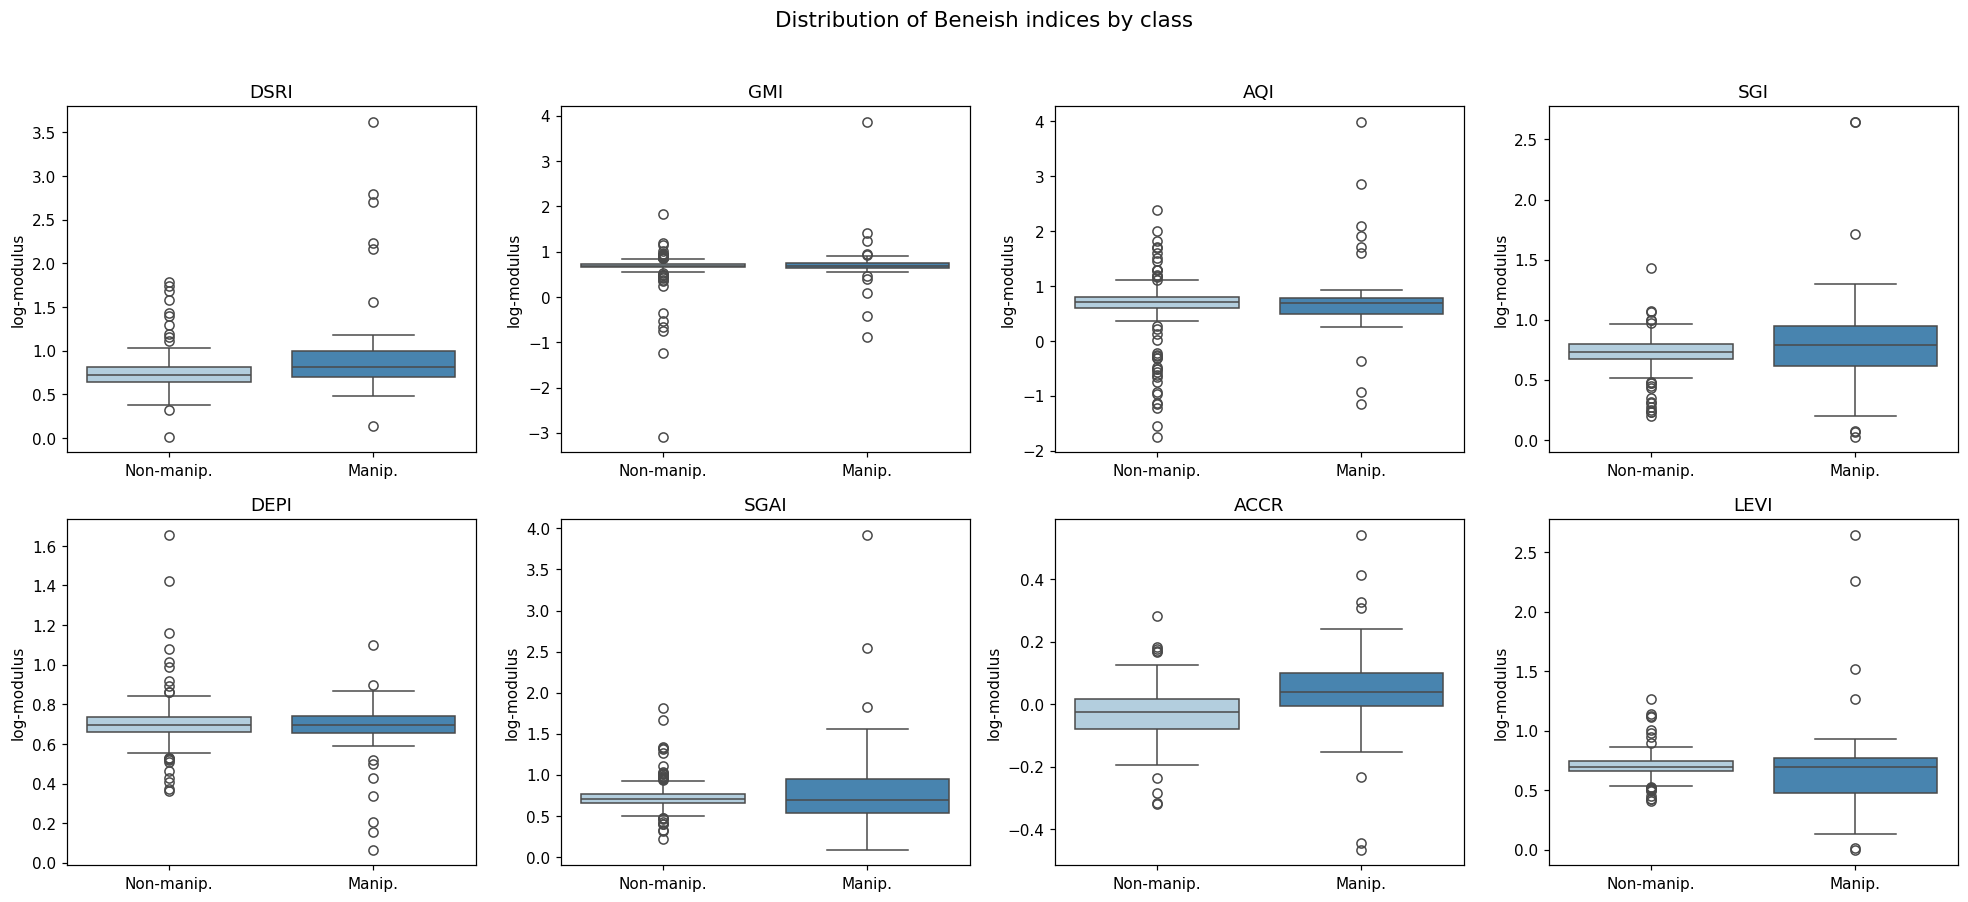

In [8]:
# Boxplots on a log-modulus scale (these ratios have extreme right tails)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), X_COLS):
    plot_df = df[[c, TARGET]].copy()
    plot_df['scaled'] = np.sign(plot_df[c]) * np.log1p(np.abs(plot_df[c]))
    sns.boxplot(data=plot_df, x=TARGET, y='scaled', ax=ax, palette='Blues')
    ax.set_title(c); ax.set_xlabel(''); ax.set_ylabel('log-modulus')
    ax.set_xticklabels(['Non-manip.', 'Manip.'])
plt.suptitle('Distribution of Beneish indices by class', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

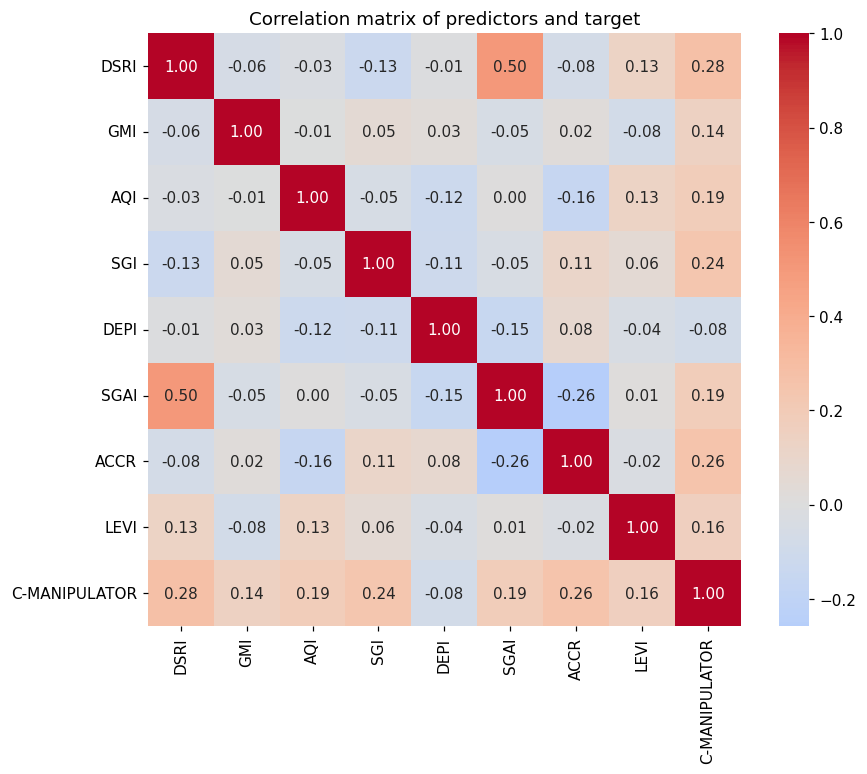

In [9]:
plt.figure(figsize=(9,7))
sns.heatmap(df[X_COLS + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix of predictors and target')
plt.show()

## 2.2 Train/test split

70:30 stratified split. **No resampling is applied.** The training sample keeps its natural 17.5%
manipulator rate so that coefficients, standard errors and p-values are estimated from independent
observations; the test set is stratified so that it **preserves the study sample's class distribution**.
Note that this is the *sample* prevalence, not a live population prevalence — Q5 addresses the gap
between the two explicitly.

In [10]:
X = df[X_COLS].astype(float)
y = df[TARGET].astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print('Train:', X_train.shape, '| manipulators:', int(Y_train.sum()), f'({Y_train.mean():.3f})')
print('Test :', X_test.shape,  '| manipulators:', int(Y_test.sum()),  f'({Y_test.mean():.3f})')

n_events = int(Y_train.sum())
print()
print(f'Events per variable, 8-predictor model : {n_events}/8 = {n_events/8:.1f}')
print(f'Events per variable, 5-predictor model : {n_events}/5 = {n_events/5:.1f}')
print('Both are below the conventional minimum of 10 EPV -- interpret coefficient magnitudes cautiously.')

Train: (154, 8) | manipulators: 27 (0.175)
Test : (66, 8) | manipulators: 12 (0.182)

Events per variable, 8-predictor model : 27/8 = 3.4
Events per variable, 5-predictor model : 27/5 = 5.4
Both are below the conventional minimum of 10 EPV -- interpret coefficient magnitudes cautiously.


## 2.3 Full logistic regression model (all 8 predictors) and separation diagnostics

In [11]:
X_train_c   = add_const(X_train)
logit_full  = fit_logit(Y_train, X_train_c)
print(logit_full.summary())

                           Logit Regression Results                           
No. Observations : 154          Log-Likelihood   :   -39.7275
Df Model         : 8            LL-Null          :   -71.4913
Df Residuals     : 145          Pseudo R-squ.    :     0.4443
Converged        : True         AIC / BIC        :  97.45 / 124.79
         coef  std err       z  P>|z|   [0.025  0.975]
const -8.9107   1.8953 -4.7014 0.0000 -12.6254 -5.1959
DSRI   1.2061   0.4161  2.8986 0.0037   0.3906  2.0216
GMI    1.2815   0.4596  2.7883 0.0053   0.3807  2.1823
AQI    0.7060   0.1881  3.7524 0.0002   0.3372  1.0748
SGI    2.4418   0.7065  3.4564 0.0005   1.0572  3.8265
DEPI   0.2319   0.5579  0.4156 0.6777  -0.8616  1.3253
SGAI  -0.0267   0.2064 -0.1293 0.8971  -0.4312  0.3779
ACCR   8.4629   2.2302  3.7947 0.0001   4.0918 12.8340
LEVI  -0.1926   0.3146 -0.6124 0.5403  -0.8092  0.4239


In [12]:
# Separation diagnostics. Quasi-separation is a real risk given only 27 manipulator events in the
# training sample (3.4 EPV for the full model), and statsmodels
# reports it as "Possibly complete quasi-separation" in the summary above when it occurs.
def separation_report(model, X_design):
    fitted = model.predict(X_design)
    print('Fitted probability range      :', f'[{fitted.min():.6f}, {fitted.max():.6f}]')
    print('Fitted probs above 0.999      :', int((fitted > 0.999).sum()))
    print('Fitted probs below 0.001      :', int((fitted < 0.001).sum()))
    print('Largest |coefficient|         :', f'{model.params.drop("const").abs().max():.3f}')
    print('Largest standard error        :', f'{model.bse.max():.3f}')
    print('Converged                     :', getattr(model, 'mle_retvals', {}).get('converged', 'n/a'))
    flag = (fitted.max() > 0.9999) or (model.bse.max() > 25)
    print('\nSeparation concern:', 'YES — interpret coefficient magnitudes with caution' if flag
          else 'no strong evidence of complete/quasi-separation in this fit')
    return flag

sep_flag = separation_report(logit_full, X_train_c)

Fitted probability range      : [0.000000, 1.000000]
Fitted probs above 0.999      : 4
Fitted probs below 0.001      : 5
Largest |coefficient|         : 8.463
Largest standard error        : 2.230
Converged                     : True

Separation concern: YES — interpret coefficient magnitudes with caution


**On quasi-separation.** With 27 manipulators in the training sample and financial ratios that contain
extreme values (AQI reaches 52.9, SGAI 49.3), logistic regression can find a linear combination that
separates the classes almost perfectly. Where that happens the likelihood is maximised as coefficients
diverge, so the MLE does not properly converge, standard errors inflate and individual coefficient
magnitudes become uninterpretable — the *direction* of an effect remains meaningful but its *size* does
not. The diagnostic above reports whether this fit is affected. Because it is a live risk at this sample
size, Section 2.5 refits the model with L2 regularisation and confirms that the substantive conclusions
do not depend on the unpenalised estimates.

In [13]:
X_vif = X_train_c.drop(columns=['const'], errors='ignore').astype(float)
if HAS_STATSMODELS:
    vif_vals = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
                         index=X_vif.columns)
else:
    vif_vals = vif(X_vif)
vif_vals = vif_vals.sort_values(ascending=False)

print('Variance Inflation Factors:'); print(vif_vals.round(2))
high_vif = vif_vals[vif_vals > 5]
print('\nVIF > 5:', list(high_vif.index) if len(high_vif) else 'none — no multicollinearity concern')

Variance Inflation Factors:
SGAI   1.5800
DSRI   1.4800
ACCR   1.1300
LEVI   1.0900
AQI    1.0800
DEPI   1.0500
SGI    1.0400
GMI    1.0200
dtype: float64

VIF > 5: none — no multicollinearity concern


In [14]:
def get_significant_variables(model, alpha=0.05):
    # Predictors (excluding the intercept) significant at the given alpha
    p = model.pvalues.drop('const', errors='ignore')
    return list(p[p <= alpha].index)

significant_vars = get_significant_variables(logit_full)
print('Significant at 5% :', significant_vars)
print('Not significant   :', [c for c in X_COLS if c not in significant_vars])

Significant at 5% : ['DSRI', 'GMI', 'AQI', 'SGI', 'ACCR']
Not significant   : ['DEPI', 'SGAI', 'LEVI']


## 2.4 Why inference is not done on an oversampled sample

Rebalancing to 50:50 by duplicating manipulators is a legitimate *predictive* device, but it is not a
source of new information. Duplicated rows are perfectly correlated with their originals, so the
likelihood behaves as though the sample were larger than it is, standard errors shrink and p-values fall.
The cell below fits the same specification both ways so the effect is visible rather than asserted.

In [15]:
# Oversample the training set to 50:50 -- for DEMONSTRATION of the inference hazard only
idx     = np.arange(len(Y_train))
min_idx = idx[Y_train.values == 1]; maj_idx = idx[Y_train.values == 0]
rs      = np.random.RandomState(RANDOM_STATE)
bal_idx = np.concatenate([maj_idx, rs.choice(min_idx, size=len(maj_idx), replace=True)])

X_train_bal = X_train.iloc[bal_idx].reset_index(drop=True)
Y_train_bal = Y_train.iloc[bal_idx].reset_index(drop=True)
logit_bal   = fit_logit(Y_train_bal, add_const(X_train_bal))

compare_se = pd.DataFrame({
    'SE (original sample, n=%d)' % len(Y_train)        : logit_full.bse,
    'SE (oversampled, n=%d)'     % len(Y_train_bal)    : logit_bal.bse,
    'p-value (original)'                               : logit_full.pvalues,
    'p-value (oversampled)'                            : logit_bal.pvalues,
})
compare_se['SE shrinkage'] = (1 - compare_se.iloc[:,1] / compare_se.iloc[:,0]).map(lambda v: f'{v:.0%}')
compare_se.round(4)

,"SE (original sample, n=154)","SE (oversampled, n=254)",p-value (original),p-value (oversampled),SE shrinkage
const,1.8953,1.5535,0.0000,0.0000,18%
DSRI,0.4161,0.3653,0.0037,0.0000,12%
GMI,0.4596,0.4253,0.0053,0.0000,7%
AQI,0.1881,0.1545,0.0002,0.0000,18%
SGI,0.7065,0.6074,0.0005,0.0000,14%
DEPI,0.5579,0.4992,0.6777,0.8518,11%
SGAI,0.2064,0.1496,0.8971,0.1637,28%
ACCR,2.2302,1.4507,0.0001,0.0000,35%
LEVI,0.3146,0.2486,0.5403,0.0363,21%


Standard errors fall across every coefficient — most sharply on the strongest predictors — and several
p-values drop by an order of magnitude, purely because rows were copied. **LEVI is the clearest
casualty:** it is comfortably insignificant on the original sample but crosses the 5% line once the
duplicates are added. Reporting the oversampled p-values would have led us to retain a variable the
honest sample does not support.

> *Statement for the report:* "To avoid artificially narrowing standard errors through duplicated
> observations, all inferential statistics were obtained from the original training sample; imbalance was
> addressed at the decision-threshold and class-weighting stages of predictive modelling."

## 2.5 Reduced (final) model, and regularised robustness check

In [16]:
final_logit_model = fit_logit(Y_train, add_const(X_train[significant_vars]))
print(final_logit_model.summary())
_ = separation_report(final_logit_model, add_const(X_train[significant_vars]))

                           Logit Regression Results                           
No. Observations : 154          Log-Likelihood   :   -39.9689
Df Model         : 5            LL-Null          :   -71.4913
Df Residuals     : 148          Pseudo R-squ.    :     0.4409
Converged        : True         AIC / BIC        :  91.94 / 110.16
         coef  std err       z  P>|z|   [0.025  0.975]
const -8.6055   1.6895 -5.0935 0.0000 -11.9169 -5.2941
DSRI   1.1107   0.3521  3.1547 0.0016   0.4206  1.8007
GMI    1.2385   0.4448  2.7841 0.0054   0.3666  2.1104
AQI    0.6850   0.1855  3.6931 0.0002   0.3215  1.0485
SGI    2.3829   0.6924  3.4414 0.0006   1.0257  3.7400
ACCR   8.4436   2.2304  3.7857 0.0002   4.0721 12.8151
Fitted probability range      : [0.000000, 1.000000]
Fitted probs above 0.999      : 4
Fitted probs below 0.001      : 5
Largest |coefficient|         : 8.444
Largest standard error        : 2.230
Converged                     : True

Separation concern: YES — interpret coefficient 

In [17]:
coef_tbl = pd.DataFrame({
    'Coefficient': final_logit_model.params,
    'Std. Error' : final_logit_model.bse,
    'z'          : final_logit_model.tvalues,
    'p-value'    : final_logit_model.pvalues,
    'Odds Ratio' : np.exp(final_logit_model.params)})
ci = final_logit_model.conf_int()
coef_tbl['OR 2.5%'] = np.exp(ci[0]); coef_tbl['OR 97.5%'] = np.exp(ci[1])

# Per-unit odds ratios are not comparable across indices because the indices differ wildly in scale
# (ACCR has an IQR of ~0.1, DSRI ~0.4). Rescale each effect to a one-interquartile-range move.
# IQR rather than SD, because these ratios have extreme tails that inflate the standard deviation.
iqr = X_train[significant_vars].quantile(0.75) - X_train[significant_vars].quantile(0.25)
coef_tbl['IQR of predictor'] = iqr
coef_tbl['Effect per IQR (log-odds)'] = final_logit_model.params[significant_vars] * iqr
coef_tbl['OR per IQR'] = np.exp(coef_tbl['Effect per IQR (log-odds)'])
coef_tbl.round(4)

,Coefficient,Std. Error,z,p-value,Odds Ratio,OR 2.5%,OR 97.5%,IQR of predictor,Effect per IQR (log-odds),OR per IQR
const,-8.6055,1.6895,-5.0935,0.0000,0.0002,0.0000,0.0050,NaN,NaN,NaN
DSRI,1.1107,0.3521,3.1547,0.0016,3.0364,1.5229,6.0541,0.4270,0.4743,1.6068
GMI,1.2385,0.4448,2.7841,0.0054,3.4504,1.4429,8.2513,0.1881,0.2329,1.2623
AQI,0.6850,0.1855,3.6931,0.0002,1.9838,1.3791,2.8534,0.4674,0.3202,1.3774
SGI,2.3829,0.6924,3.4414,0.0006,10.8358,2.7892,42.0964,0.2793,0.6655,1.9455
ACCR,8.4436,2.2304,3.7857,0.0002,"4,645.2707",58.6797,"367,734.5060",0.0949,0.8014,2.2287


In [18]:
# Does the choice of variable set matter? AIC/BIC and repeated CV, both computed on the TRAINING set only.
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
spec_rows = []
for name, cols in [('Reduced (significant only)', significant_vars),
                   ('Reduced + LEVI',             significant_vars + ['LEVI']),
                   ('Full (all 8)',               X_COLS)]:
    mdl = fit_logit(Y_train, add_const(X_train[cols]))
    est = LogisticRegression(C=1e6, max_iter=10000)
    auc = cross_val_score(est, X_train[cols], Y_train, cv=cv_rep, scoring='roc_auc')
    ap  = cross_val_score(est, X_train[cols], Y_train, cv=cv_rep, scoring='average_precision')
    spec_rows.append([name, len(cols), mdl.aic, mdl.bic, mdl.prsquared, auc.mean(), ap.mean()])

pd.DataFrame(spec_rows, columns=['Specification','k','AIC','BIC','McFadden R2','CV ROC-AUC','CV PR-AUC']).round(4)

,Specification,k,AIC,BIC,McFadden R2,CV ROC-AUC,CV PR-AUC
0,Reduced (significant only),5,91.9378,110.1596,0.4409,0.8697,0.7110
1,Reduced + LEVI,6,93.6429,114.9016,0.4430,0.8182,0.6648
2,Full (all 8),8,97.4550,124.7875,0.4443,0.8009,0.6305


The reduced specification is preferred on every criterion: lowest AIC and BIC, and cross-validated
discrimination that is equal to or better than the larger models. Adding LEVI back changes nothing.

**On variable selection language.** DEPI, SGAI and LEVI are dropped because they show **no incremental
contribution** once the retained indices are in the model — not because they are theoretically
irrelevant. LEVI in particular is a well-motivated control (debt covenants create a manipulation motive)
and is retained in the published Beneish specification; on this sample it simply does not earn its place,
and the comparison above confirms that excluding it costs nothing.

In [19]:
# L2-regularised logistic regression as a robustness check against sparse-data instability.
# Features MUST be standardised first: an L2 penalty is scale-dependent, so without scaling it would
# crush ACCR (tiny scale, large coefficient) and barely touch the others.
l2_pipe = Pipeline([('scaler', StandardScaler()),
                    ('logit', LogisticRegressionCV(Cs=np.logspace(-3, 3, 13),
                                                   cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                                                   scoring='roc_auc', max_iter=10000))])
l2_pipe.fit(X_train[significant_vars], Y_train)
C_chosen = l2_pipe.named_steps['logit'].C_[0]

# Compare on the standardised scale so the two sets of coefficients are directly comparable
sd_train  = X_train[significant_vars].std()
unpen_std = final_logit_model.params[significant_vars] * sd_train

robust = pd.DataFrame({'Unpenalised (standardised)': unpen_std,
                       f'L2, CV-chosen C={C_chosen:.2f}': pd.Series(l2_pipe.named_steps['logit'].coef_[0],
                                                                    index=significant_vars)})
for C in [0.1, 1.0, 10.0]:
    p = Pipeline([('s', StandardScaler()), ('l', LogisticRegression(C=C, max_iter=10000))])
    p.fit(X_train[significant_vars], Y_train)
    robust[f'L2, C={C}'] = p.named_steps['l'].coef_[0]

print(robust.round(4))
print('\nAll coefficients positive in every specification:', bool((robust > 0).all().all()))
print('Importance ordering identical across specifications:',
      all(robust[c].abs().rank(ascending=False).equals(robust.iloc[:,0].abs().rank(ascending=False))
          for c in robust.columns))

# Predictive comparison stays on the TRAINING partition -- the test set is not opened until Section 4.7
inner = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
auc_unpen = cross_val_score(LogisticRegression(C=1e6, max_iter=10000),
                            X_train[significant_vars], Y_train, cv=inner, scoring='roc_auc').mean()
auc_l2    = cross_val_score(l2_pipe, X_train[significant_vars], Y_train, cv=inner, scoring='roc_auc').mean()
print(f'\nCross-validation selected C = {C_chosen:.2f}  (large C = light penalty)')
print(f'Training CV ROC-AUC — unpenalised    : {auc_unpen:.4f}')
print(f'Training CV ROC-AUC — L2-regularised : {auc_l2:.4f}')

      Unpenalised (standardised)  L2, CV-chosen C=316.23  ...  L2, C=1.0  L2, C=10.0
DSRI                      3.5545                  3.5097  ...     1.7864      2.9357
GMI                       5.1058                  5.0201  ...     0.6839      3.4932
AQI                       3.1180                  3.0813  ...     1.4278      2.5812
SGI                       2.5054                  2.4747  ...     1.0605      2.0516
ACCR                      1.1993                  1.1893  ...     0.8160      1.0685

[5 rows x 5 columns]

All coefficients positive in every specification: True
Importance ordering identical across specifications: False

Cross-validation selected C = 316.23  (large C = light penalty)
Training CV ROC-AUC — unpenalised    : 0.8659
Training CV ROC-AUC — L2-regularised : 0.8611


Two things to take from this. First, **cross-validation selects a very light penalty**, and the resulting
coefficients are almost identical to the unpenalised ones — the data is not asking to be regularised, which
is direct evidence that the fit is not being driven by separation-induced coefficient inflation. Second,
even at penalties heavy enough to shrink the coefficients substantially, **every sign and the ordering of
importance survive**, and cross-validated discrimination on the training set is essentially unchanged. The substantive conclusions
therefore do not rest on the unpenalised estimates — the reassurance a sparse-data logistic model needs.

In [20]:
params = final_logit_model.params
terms  = ' '.join([f"{'+' if v >= 0 else '-'} {abs(v):.4f}*{k} " for k, v in params.items() if k != 'const'])
print('Logit(P(manipulator)) = ' + f"{params['const']:.4f} " + terms)
print()
print('P(manipulator) = 1 / (1 + exp(-Logit))')

Logit(P(manipulator)) = -8.6055 + 1.1107*DSRI  + 1.2385*GMI  + 0.6850*AQI  + 2.3829*SGI  + 8.4436*ACCR 

P(manipulator) = 1 / (1 + exp(-Logit))


### Interpretation of the fitted model

Each coefficient is the change in **log-odds** per one-unit increase in the index, holding the others
constant; exponentiating gives the odds ratio. **Per-unit odds ratios are not comparable across these
predictors**, because a one-unit move means something completely different for ACCR (whose interquartile
range is about 0.1) than for DSRI (about 0.4). The `OR per IQR` column rescales every effect to a
one-interquartile-range move, which is what the ranking below uses. IQR is used rather than the standard
deviation because these ratios carry extreme tails — GMI's standard deviation is over twenty times its
IQR, so an SD-standardised coefficient would be dominated by a handful of outliers.

Ranked on that comparable scale:

1. **ACCR (accruals to total assets)** — the largest effect on a comparable scale, and the only predictor
   that is also significant univariately at any strict level. Earnings not converted into cash are the
   single strongest tell, and this survives controlling for everything else: the classic accruals anomaly.
   Its enormous *per-unit* odds ratio is an artefact of its tiny scale, not evidence of a bigger effect.
2. **SGI (sales growth)** — rapid growth creates both the pressure to sustain the streak and the cover to
   hide a shortfall, and it is the variable most under management's narrative control.
3. **DSRI (receivables)** — sales booked but not collected. Channel stuffing, aggressive revenue
   recognition and related-party sales surface here first.
4. **AQI (asset quality)** — a rising share of soft, non-current assets is where capitalised costs get parked.
5. **GMI (gross margin deterioration)** — supplies the motive: firms whose real economics are worsening
   are the ones under pressure to close the gap on paper. Smallest effect of the five once rescaled.
- **DEPI, SGAI and LEVI add nothing incrementally.** Depreciation-policy games and SG&A drift are too
  noisy at this sample size once accruals and receivables are in the model.

Two caveats attach to every number above. First, with only 27 manipulator events and approximately 5.4
EPV in the final model, the confidence intervals are wide — read the **signs and the ordering**, not the
point estimates. Second, the model is fitted on a
sample whose manipulator rate is 17.7%, which may not represent the deployment population, so the
**intercept is not calibrated for deployment**; Q5 corrects this.

---
# Q3. Model goodness, accuracy and insights  *(10 marks)*

## 3.1 Overall fit statistics

In [21]:
lr_stat = 2 * (final_logit_model.llf - final_logit_model.llnull)
lr_df   = len(significant_vars)
lr_p    = stats.chi2.sf(lr_stat, lr_df)

print(f"Log-likelihood (fitted)     : {final_logit_model.llf:.3f}")
print(f"Log-likelihood (null)       : {final_logit_model.llnull:.3f}")
print(f"Likelihood-ratio chi-square : {lr_stat:.3f} on {lr_df} df, p = {lr_p:.3e}")
print(f"McFadden pseudo R-squared   : {final_logit_model.prsquared:.4f}")
print(f"AIC / BIC                   : {final_logit_model.aic:.2f} / {final_logit_model.bic:.2f}")

Log-likelihood (fitted)     : -39.969
Log-likelihood (null)       : -71.491
Likelihood-ratio chi-square : 63.045 on 5 df, p = 2.850e-12
McFadden pseudo R-squared   : 0.4409
AIC / BIC                   : 91.94 / 110.16


The likelihood-ratio test rejects the null that all slopes are zero at any conventional level. A McFadden
pseudo-R² in the 0.4 range indicates a very good fit by McFadden's own guidance (0.2–0.4 already
represents excellent fit); the statistic is **not** comparable to an OLS R² and should not be read as
"proportion of variance explained".

## 3.2 Selecting the decision threshold — on training data only

The 0.5 cut-off implicitly assumes a false positive and a false negative cost the same. They do not. A
**false negative** means a manipulator is cleared and a client lends, invests or signs an audit opinion on
fraudulent statements. A **false positive** costs one unnecessary review.

The cut-off is therefore chosen to minimise expected cost — but selected using **out-of-fold predictions
generated inside the training partition**, never on the test set. It is then frozen.

In [22]:
# Out-of-fold probabilities WITHIN the training set (test set is not touched)
inner_cv  = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof_est   = LogisticRegression(C=1e6, max_iter=10000)       # unpenalised, matches the statsmodels fit
oof_prob  = cross_val_predict(oof_est, X_train[significant_vars], Y_train,
                              cv=inner_cv, method='predict_proba')[:, 1]

print(f'Out-of-fold ROC-AUC (training) : {roc_auc_score(Y_train, oof_prob):.4f}')
print(f'Out-of-fold PR-AUC  (training) : {average_precision_score(Y_train, oof_prob):.4f}'
      f'   (baseline = prevalence {Y_train.mean():.3f})')

Out-of-fold ROC-AUC (training) : 0.8437
Out-of-fold PR-AUC  (training) : 0.6492   (baseline = prevalence 0.175)


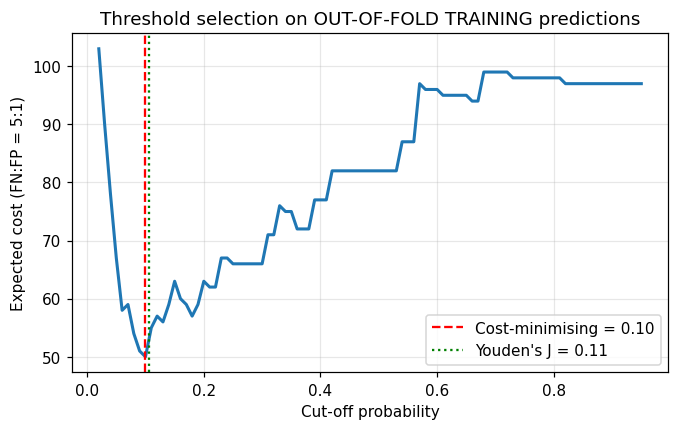

Threshold selected on training CV : 0.10  (frozen from here on)
Youden's J on the same OOF data   : 0.11


In [23]:
# ASSUMPTION (scenario parameter, not a fact from the case): a missed manipulator costs 5x a wasted review.
COST_RATIO = 5      # cost(FN) : cost(FP)

def total_cost(actual, predicted, ratio):
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0,1]).ravel()
    return fn * ratio + fp * 1

THRESHOLDS = np.arange(0.02, 0.96, 0.01)
cost_curve = pd.DataFrame({
    'threshold': THRESHOLDS,
    'cost': [total_cost(Y_train, (oof_prob >= t).astype(int), COST_RATIO) for t in THRESHOLDS]})

CHOSEN_THRESHOLD = float(cost_curve.loc[cost_curve['cost'].idxmin(), 'threshold'])

fpr_o, tpr_o, thr_o = roc_curve(Y_train, oof_prob)
youden_threshold = float(thr_o[(tpr_o - fpr_o).argmax()])

plt.figure(figsize=(7,4))
plt.plot(cost_curve['threshold'], cost_curve['cost'], lw=2)
plt.axvline(CHOSEN_THRESHOLD, color='red', ls='--', label=f'Cost-minimising = {CHOSEN_THRESHOLD:.2f}')
plt.axvline(youden_threshold, color='green', ls=':', label=f"Youden's J = {youden_threshold:.2f}")
plt.xlabel('Cut-off probability'); plt.ylabel(f'Expected cost (FN:FP = {COST_RATIO}:1)')
plt.title('Threshold selection on OUT-OF-FOLD TRAINING predictions')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f'Threshold selected on training CV : {CHOSEN_THRESHOLD:.2f}  (frozen from here on)')
print(f"Youden's J on the same OOF data   : {youden_threshold:.2f}")

## 3.3 One evaluation on the untouched test set

The threshold above was fixed without any sight of the test set. It is now applied **once**.

*(For transparency about ordering: the logistic model was chosen as the production model on the
training-set cross-validation evidence set out in Section 4.6, and its cut-off on the out-of-fold training
predictions in Section 3.2. Both decisions were made before any test-set number was computed. This
section reports the resulting locked model's single test evaluation; the alternative models are scored on
the same test set together in Section 4.7.)*

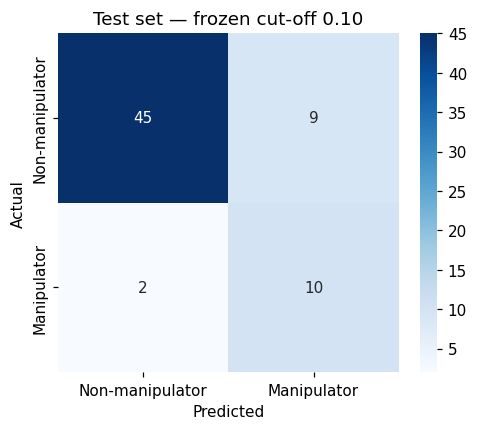

                 precision    recall  f1-score   support

Non-manipulator      0.957     0.833     0.891        54
    Manipulator      0.526     0.833     0.645        12

       accuracy                          0.833        66
      macro avg      0.742     0.833     0.768        66
   weighted avg      0.879     0.833     0.846        66



In [24]:
y_pred_prob = final_logit_model.predict(add_const(X_test[significant_vars]))
y_pred      = (y_pred_prob >= CHOSEN_THRESHOLD).astype(int)

Y_pred_df = pd.DataFrame({'actual': Y_test.values,
                          'predicted_prob': y_pred_prob.values,
                          'predicted': y_pred.values})

def draw_cm(actual, predicted, title='Confusion Matrix'):
    cm = metrics.confusion_matrix(actual, predicted, labels=[0, 1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-manipulator', 'Manipulator'],
                yticklabels=['Non-manipulator', 'Manipulator'])
    plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.title(title); plt.show()
    return cm

_ = draw_cm(Y_test, y_pred, f'Test set — frozen cut-off {CHOSEN_THRESHOLD:.2f}')
print(classification_report(Y_test, y_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

In [25]:
def report_metrics(actual, predicted, prob=None, label=''):
    tn, fp, fn, tp = metrics.confusion_matrix(actual, predicted, labels=[0,1]).ravel()
    out = {'Model/Cut-off': label,
           'Accuracy'   : accuracy_score(actual, predicted),
           'Sensitivity': tp / (tp + fn) if (tp+fn) else np.nan,
           'Specificity': tn / (tn + fp) if (tn+fp) else np.nan,
           'Precision'  : precision_score(actual, predicted, zero_division=0),
           'F1'         : f1_score(actual, predicted, zero_division=0),
           'False Pos'  : fp, 'False Neg': fn}
    if prob is not None:
        out['ROC-AUC'] = roc_auc_score(actual, prob)
        out['PR-AUC']  = average_precision_score(actual, prob)
    return out

results = [report_metrics(Y_test, (y_pred_prob >= 0.5).astype(int), y_pred_prob, 'Logistic @ 0.50 (default)'),
           report_metrics(Y_test, y_pred, y_pred_prob, f'Logistic @ {CHOSEN_THRESHOLD:.2f} (CV-selected)')]
pd.DataFrame(results).round(4)

,Model/Cut-off,Accuracy,Sensitivity,Specificity,Precision,F1,False Pos,False Neg,ROC-AUC,PR-AUC
0,Logistic @ 0.50 (default),0.8636,0.3333,0.9815,0.8000,0.4706,1,8,0.9228,0.7293
1,Logistic @ 0.10 (CV-selected),0.8333,0.8333,0.8333,0.5263,0.6452,9,2,0.9228,0.7293


Moving from the default 0.5 to the cost-selected cut-off converts several false negatives into false
positives at a small cost in overall accuracy — exactly the trade a screening tool should make. Because
ROC-AUC and PR-AUC are threshold-independent they are unchanged; the cut-off is a *decision* choice, not
a modelling one.

## 3.4 Discrimination and calibration

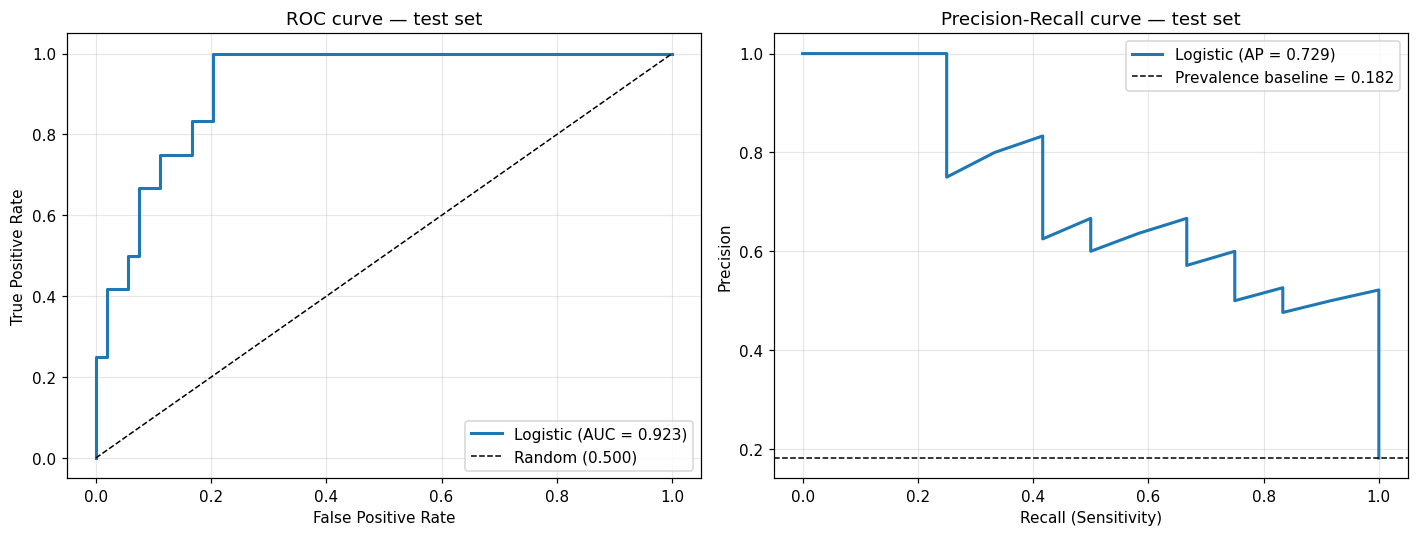

ROC-AUC : 0.9228
PR-AUC  : 0.7293   vs prevalence baseline 0.1818  (lift = 4.0x)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'Logistic (AUC = {roc_auc_score(Y_test, y_pred_prob):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve — test set'); axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# Precision-Recall
prec, rec, _ = precision_recall_curve(Y_test, y_pred_prob)
ap = average_precision_score(Y_test, y_pred_prob)
baseline = Y_test.mean()
axes[1].plot(rec, prec, lw=2, label=f'Logistic (AP = {ap:.3f})')
axes[1].axhline(baseline, color='k', ls='--', lw=1, label=f'Prevalence baseline = {baseline:.3f}')
axes[1].set_xlabel('Recall (Sensitivity)'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve — test set'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'ROC-AUC : {roc_auc_score(Y_test, y_pred_prob):.4f}')
print(f'PR-AUC  : {ap:.4f}   vs prevalence baseline {baseline:.4f}  '
      f'(lift = {ap/baseline:.1f}x)')

Because manipulators are only 17.7% of observations, ROC-AUC on its own can look optimistic. Average
precision is therefore reported against the naïve baseline equal to the prevalence: a random classifier
scores AP = 0.18, so the model's AP represents a substantial multiple of chance and confirms that the
ROC figure is not an artefact of imbalance.

**Read the calibration results as adequate rather than strong.** The reliability curve below tracks the
diagonal in the lowest and highest risk bins but shows the model under-predicting in the middle quintiles,
and the Hosmer-Lemeshow p-value is marginal. The practical reading is that the **ranking** is reliable
while the **absolute probability level** deserves care — one more reason the prior correction in Q5 matters.

Brier score (model)              : 0.1054
Brier score (predict prevalence) : 0.1488
Brier skill score                : 0.2912   (1 = perfect, 0 = no better than base rate)


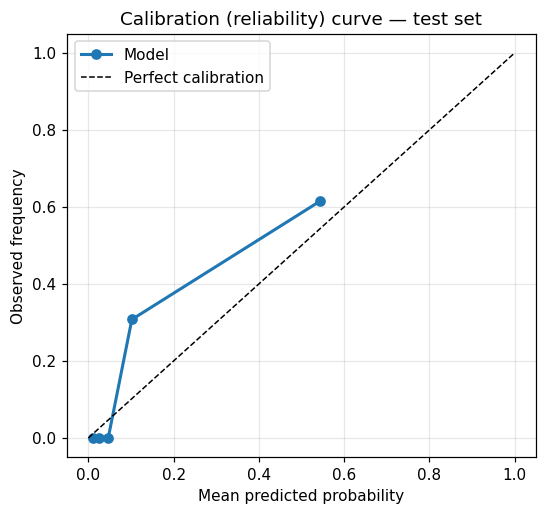

In [27]:
# Calibration: Brier score and reliability curve
brier = brier_score_loss(Y_test, y_pred_prob)
brier_baseline = brier_score_loss(Y_test, np.full(len(Y_test), Y_test.mean()))
print(f'Brier score (model)              : {brier:.4f}')
print(f'Brier score (predict prevalence) : {brier_baseline:.4f}')
print(f'Brier skill score                : {1 - brier/brier_baseline:.4f}   (1 = perfect, 0 = no better than base rate)')

prob_true, prob_pred = calibration_curve(Y_test, y_pred_prob, n_bins=5, strategy='quantile')
plt.figure(figsize=(5.5,5))
plt.plot(prob_pred, prob_true, 'o-', lw=2, label='Model')
plt.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed frequency')
plt.title('Calibration (reliability) curve — test set'); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [28]:
# Hosmer-Lemeshow goodness-of-fit test
def hosmer_lemeshow(y_true, y_prob, g=5):
    d = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    d['grp'] = pd.qcut(d['p'].rank(method='first'), g, labels=False)
    t = d.groupby('grp').agg(obs=('y','sum'), n=('y','size'), exp=('p','sum'))
    t['obs0'] = t['n'] - t['obs']; t['exp0'] = t['n'] - t['exp']
    hl = (((t['obs']-t['exp'])**2 / t['exp']) + ((t['obs0']-t['exp0'])**2 / t['exp0'])).sum()
    return hl, stats.chi2.sf(hl, g-2), t

hl_stat, hl_p, hl_table = hosmer_lemeshow(Y_test, y_pred_prob, g=5)
print(f'Hosmer-Lemeshow chi-square = {hl_stat:.3f}, p = {hl_p:.4f}')
print('A large p-value means there is NO STATISTICALLY DETECTABLE EVIDENCE OF LACK OF FIT.')
print('It is not positive proof of good calibration -- with 66 test observations the test has low power.')
hl_table.round(3)

Hosmer-Lemeshow chi-square = 7.403, p = 0.0601
A large p-value means there is NO STATISTICALLY DETECTABLE EVIDENCE OF LACK OF FIT.
It is not positive proof of good calibration -- with 66 test observations the test has low power.


,obs,n,exp,obs0,exp0
grp,,,,,
0,0,14,0.1560,14,13.8440
1,0,13,0.3300,13,12.6700
2,0,13,0.6060,13,12.3940
3,4,13,1.3260,9,11.6740
4,8,13,7.0730,5,5.9270


## 3.5 Residual and influence diagnostics

The assignment asks for graphical diagnostics such as residual and P-P plots, so they are provided.
One qualification matters:

> **Unlike linear regression, logistic regression does not assume normally distributed residuals.** The
> Q-Q plot below is used to identify unusual observations, not as a formal normality test. For a binary
> outcome the informative diagnostics are **calibration** (Section 3.4) and **influence**
> (Cook's distance, below).

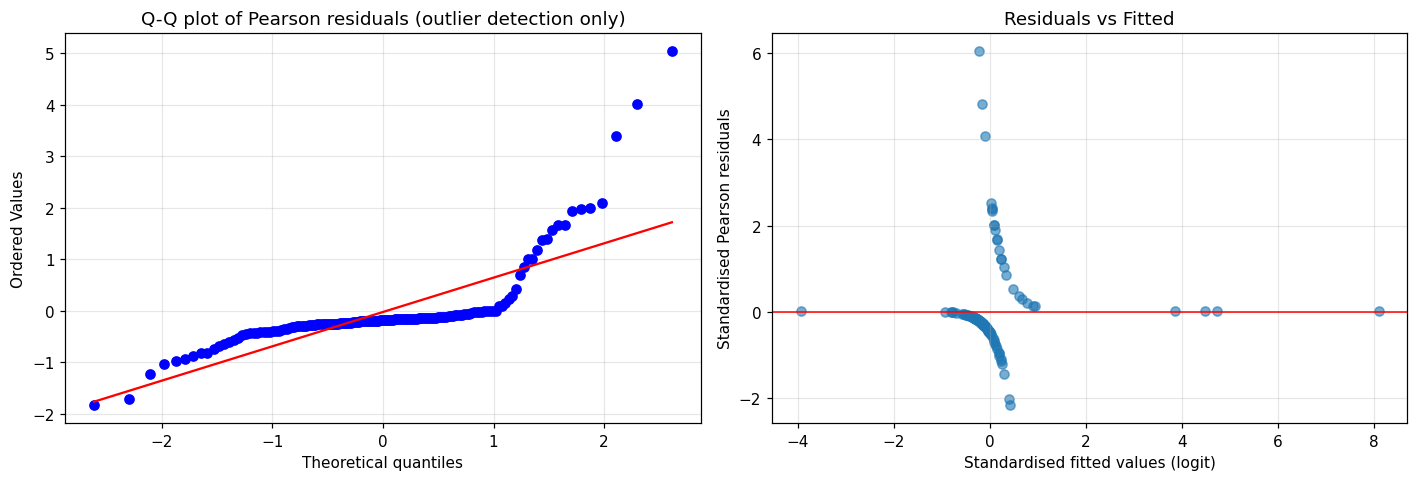

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
stats.probplot(final_logit_model.resid_pearson, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot of Pearson residuals (outlier detection only)')
axes[0].grid(alpha=0.3)

def standardize(v): return (v - v.mean()) / v.std()
axes[1].scatter(standardize(final_logit_model.fittedvalues),
                standardize(pd.Series(final_logit_model.resid_pearson)), alpha=0.6)
axes[1].axhline(0, color='red', lw=1)
axes[1].set_xlabel('Standardised fitted values (logit)'); axes[1].set_ylabel('Standardised Pearson residuals')
axes[1].set_title('Residuals vs Fitted'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

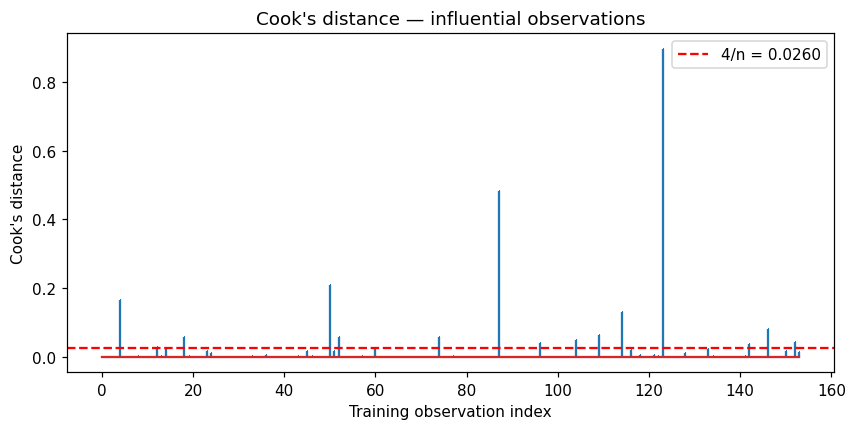

Observations above 4/n: 16 of 154
These are firms with extreme ratio values; they are retained because they are genuine data, but
they are one reason coefficient magnitudes should be read cautiously.


In [30]:
influence = final_logit_model.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

plt.figure(figsize=(9,4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
plt.axhline(threshold, color='red', ls='--', label=f'4/n = {threshold:.4f}')
plt.xlabel('Training observation index'); plt.ylabel("Cook's distance")
plt.title("Cook's distance — influential observations"); plt.legend(); plt.show()

n_infl = int((cooks_d > threshold).sum())
print(f'Observations above 4/n: {n_infl} of {len(cooks_d)}')
print('These are firms with extreme ratio values; they are retained because they are genuine data, but')
print('they are one reason coefficient magnitudes should be read cautiously.')

## 3.6 Insights from the logistic model

1. **Cash-flow quality is the dominant signal.** ACCR has the largest effect of any variable. Firms whose
   reported profit is not backed by operating cash are the highest-risk population, after controlling for
   growth, receivables and margins.
2. **Growth plus receivables is the classic manipulation fingerprint.** SGI and DSRI are both strongly
   positive. A fast-growing firm whose receivables grow faster still is the archetype — revenue is being
   recognised ahead of collection.
3. **Deteriorating fundamentals supply the motive.** GMI enters positively: firms whose real margins are
   falling are the ones under pressure to close the gap on paper.
4. **Three of the eight Beneish variables add nothing incremental here.** The final model is more
   parsimonious than the published eight-variable specification without losing discrimination (Section 2.5).
5. **Discrimination is strong; precision is not.** ROC-AUC around 0.92 means the model ranks a randomly
   chosen manipulator above a randomly chosen non-manipulator roughly 92% of the time. But at the
   operating cut-off most flagged firms are still innocent — which is inherent to screening for a rare
   event, and is why the output must be read as "investigate first", never as "this firm committed fraud".
6. **The statistical caveats are real and should be disclosed:** the fitted model uses 27 manipulators in
   the training sample, equivalent to approximately 5.4 events per variable in the final five-predictor
   specification, with wide confidence intervals and a live risk of quasi-separation. The sample
   prevalence of 17.7% may also not represent the deployment population. Sections 2.3, 2.5 and Q5 address
   each in turn.

---
# Q4. Alternative machine-learning models  *(8 marks)*

Four alternatives — a single decision tree (for the interpretable *rules* the case asks for), a random
forest, gradient boosting and KNN — benchmarked against the published **Beneish M-score**.

Class imbalance is addressed **where directly supported**: class weights are used for the decision tree
and the random forest. KNN uses distance weighting and standardisation, while all models are evaluated
using imbalance-appropriate metrics such as sensitivity and PR-AUC. All scaling happens **inside CV
folds** (via `Pipeline`) so that no fold sees information from its own holdout.

> **Ordering matters here.** Sections 4.1–4.5 fit and tune each model on the **training partition only**.
> Section 4.6 compares them by repeated cross-validation, again on training data only, and selects the
> production model. Only then, in Section 4.7, is the test set scored — once, for every model at the same
> time. No test-set number is computed before the selection decision has been made.

## 4.1 Decision tree — extracting rules

In [31]:
gs_tree = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                       {'max_depth': [2,3,4,5], 'min_samples_leaf': [5,8,10,20]},
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc')
gs_tree.fit(X_train, Y_train)
clf_tree = gs_tree.best_estimator_
print('Best parameters :', gs_tree.best_params_)
print('Best CV ROC-AUC :', round(gs_tree.best_score_, 4))

Best parameters : {'max_depth': 5, 'min_samples_leaf': 5}
Best CV ROC-AUC : 0.7564


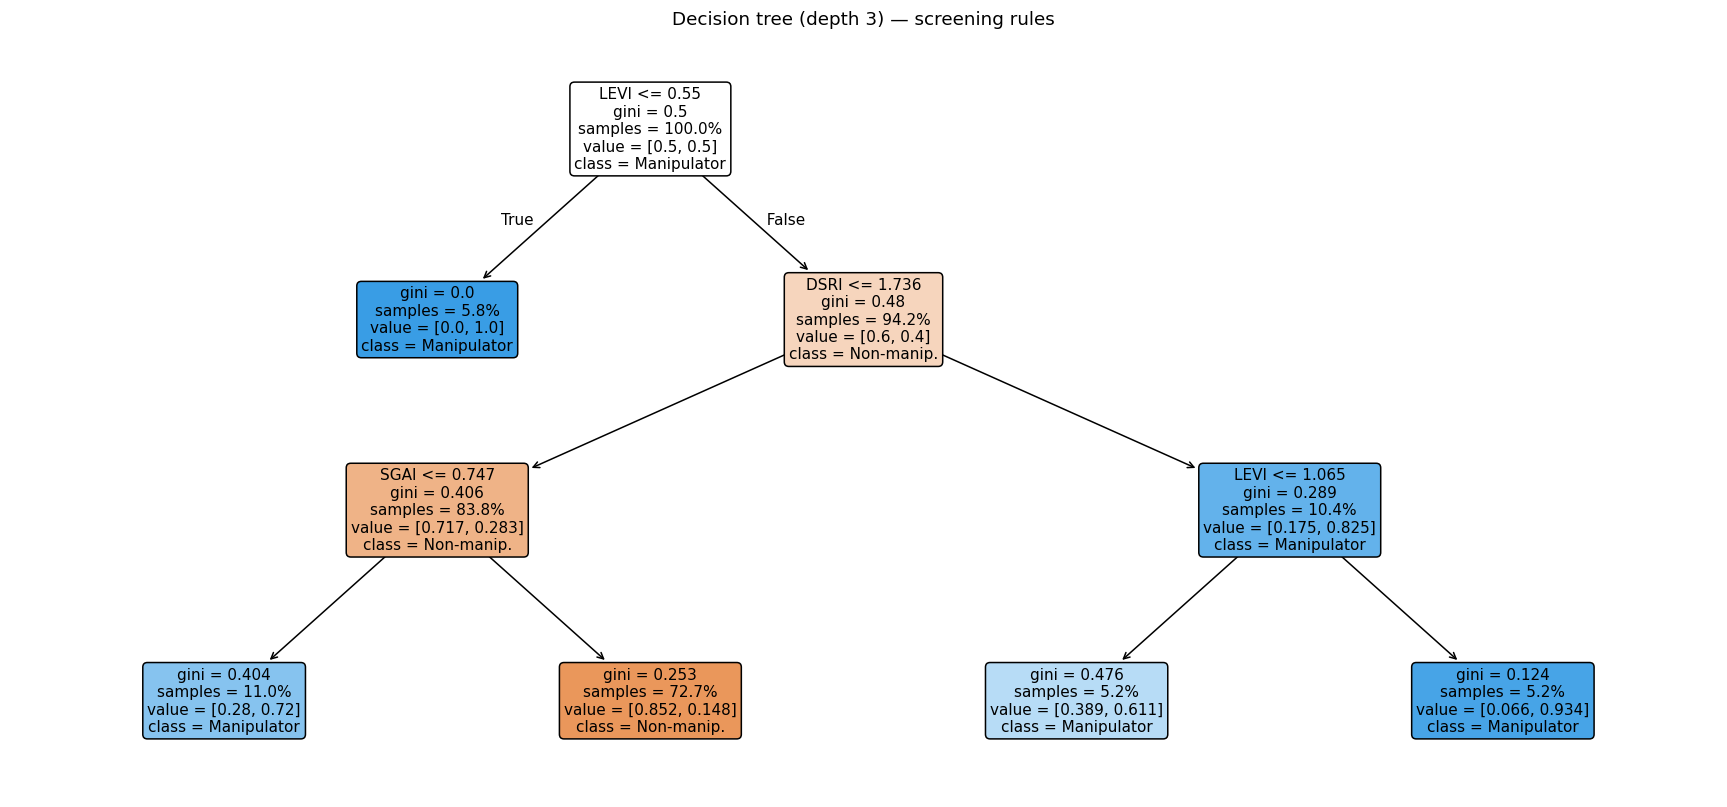

|--- LEVI <= 0.55
|   |--- class: 1
|--- LEVI >  0.55
|   |--- DSRI <= 1.74
|   |   |--- SGAI <= 0.75
|   |   |   |--- class: 1
|   |   |--- SGAI >  0.75
|   |   |   |--- class: 0
|   |--- DSRI >  1.74
|   |   |--- LEVI <= 1.06
|   |   |   |--- class: 1
|   |   |--- LEVI >  1.06
|   |   |   |--- class: 1



In [32]:
rule_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                   class_weight='balanced', random_state=RANDOM_STATE).fit(X_train, Y_train)
plt.figure(figsize=(20, 9))
plot_tree(rule_tree, feature_names=X_COLS, class_names=['Non-manip.','Manipulator'],
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title('Decision tree (depth 3) — screening rules'); plt.show()
print(export_text(rule_tree, feature_names=X_COLS))

## 4.2 Random forest

In [33]:
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, max_features='sqrt',
                            class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, Y_train)
print('Random forest fitted on the training partition.')

Random forest fitted on the training partition.


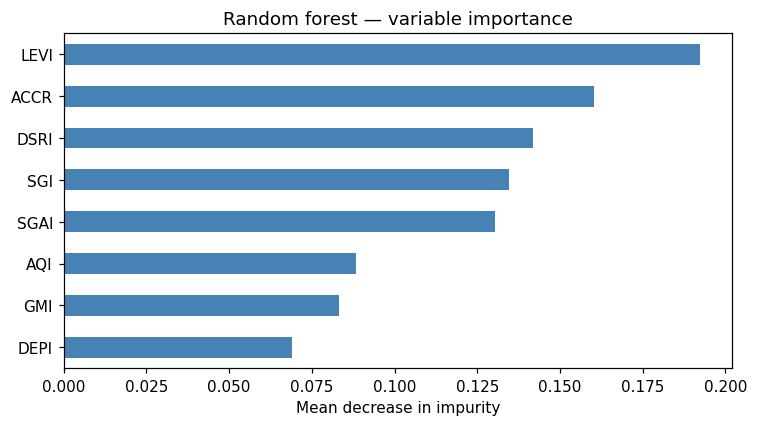

,0
LEVI,0.1923
ACCR,0.1603
DSRI,0.1418
SGI,0.1347
SGAI,0.1305
AQI,0.0882
GMI,0.0831
DEPI,0.0691


In [34]:
imp = pd.Series(rf.feature_importances_, index=X_COLS).sort_values()
plt.figure(figsize=(7,4)); imp.plot(kind='barh', color='steelblue')
plt.xlabel('Mean decrease in impurity'); plt.title('Random forest — variable importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

Impurity-based importance broadly corroborates the logistic findings, but it is biased toward continuous
variables with many possible split points and should not be treated as a substitute for the coefficient
evidence in Q2.

## 4.3 Gradient boosting (XGBoost where available)

In [35]:
try:
    from xgboost import XGBClassifier
    scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()
    boost = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                          subsample=0.9, colsample_bytree=0.9, scale_pos_weight=scale_pos_weight,
                          eval_metric='logloss', random_state=RANDOM_STATE)
    boost_name = 'XGBoost'
except ImportError:
    boost = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                                       random_state=RANDOM_STATE)
    boost_name = 'Gradient Boosting'
boost.fit(X_train, Y_train)
print(f'{boost_name} fitted on the training partition.')

Gradient Boosting fitted on the training partition.


## 4.4 K-nearest neighbours

KNN is distance-based, so features **must** be standardised — otherwise ACCR (range ≈ ±0.7) is drowned
out by AQI (range ≈ ±53). The scaler sits inside a `Pipeline` so it is fitted on each training fold only,
never on the fold's holdout. Distance weighting gives closer neighbours more influence, which partly
offsets the majority class dominating each neighbourhood.

In [36]:
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(weights='distance'))])
gs_knn = GridSearchCV(knn_pipe, {'knn__n_neighbors': [3,5,7,9,11,15]},
                      cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc')
gs_knn.fit(X_train, Y_train)
knn = gs_knn.best_estimator_
print('Best k:', gs_knn.best_params_['knn__n_neighbors'], '| CV ROC-AUC:', round(gs_knn.best_score_, 4))

Best k: 7 | CV ROC-AUC: 0.8054


## 4.5 Benchmark: the published Beneish M-score

$$M = -4.84 + 0.920\,\text{DSRI} + 0.528\,\text{GMI} + 0.404\,\text{AQI} + 0.892\,\text{SGI}
+ 0.115\,\text{DEPI} - 0.172\,\text{SGAI} + 4.679\,\text{ACCR} - 0.327\,\text{LEVI}$$

with M > −1.78 flagging a likely manipulator.

> **Read this as a benchmark, not as a cross-validated competitor.** Its coefficients are fixed
> externally (estimated on 1990s US firms) and are never refitted on this data, so it incurs no
> estimation penalty and no cross-validation cost. Comparing it to models that *are* fitted here is
> informative about variable choice, but it is not a like-for-like contest.

In [37]:
def beneish_m_score(d):
    return (-4.84 + 0.920*d['DSRI'] + 0.528*d['GMI'] + 0.404*d['AQI'] + 0.892*d['SGI']
            + 0.115*d['DEPI'] - 0.172*d['SGAI'] + 4.679*d['ACCR'] - 0.327*d['LEVI'])

df['M_SCORE'] = beneish_m_score(df)
m_train = df.loc[X_train.index, 'M_SCORE']
print('Beneish M-score on the TRAINING partition:')
print('  ROC-AUC :', round(roc_auc_score(Y_train, m_train), 4))
print('  PR-AUC  :', round(average_precision_score(Y_train, m_train), 4))

Beneish M-score on the TRAINING partition:
  ROC-AUC : 0.9122
  PR-AUC  : 0.7164


## 4.6 Model selection: repeated cross-validation, on the training set only

A single split cannot choose between models — with only 27 manipulators, moving a handful of firms
between folds swings sensitivity substantially. Repeated stratified cross-validation (five folds, five
repeats) gives a far more stable comparison.

**Every figure in the table below is computed on the 154 training firms.** Selecting a model on numbers
that include the test set would contaminate the final evaluation exactly as threshold-tuning on test data
would. Each estimator is refitted inside each fold.

In [38]:
cv_models = {
    'Logistic (reduced)': (LogisticRegression(C=1e6, max_iter=10000), significant_vars),
    'Logistic (all 8)'  : (LogisticRegression(C=1e6, max_iter=10000), X_COLS),
    'Logistic (L2, scaled + CV-tuned)': (Pipeline([('s', StandardScaler()),
                                                   ('l', LogisticRegressionCV(Cs=np.logspace(-3,3,7), cv=3,
                                                                              scoring='roc_auc', max_iter=10000))]),
                                        significant_vars),
    'Decision Tree'     : (DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                                  class_weight='balanced', random_state=RANDOM_STATE), X_COLS),
    'Random Forest'     : (RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                                  class_weight='balanced_subsample',
                                                  random_state=RANDOM_STATE, n_jobs=-1), X_COLS),
    'Gradient Boosting' : (GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                                      learning_rate=0.05, random_state=RANDOM_STATE), X_COLS),
    'KNN (scaled, k=5)' : (Pipeline([('s', StandardScaler()),
                                     ('k', KNeighborsClassifier(5, weights='distance'))]), X_COLS),
}

cv_rows = []
for name, (model, cols) in cv_models.items():
    auc = cross_val_score(model, X_train[cols], Y_train, cv=cv_rep, scoring='roc_auc', n_jobs=-1)
    ap  = cross_val_score(model, X_train[cols], Y_train, cv=cv_rep, scoring='average_precision', n_jobs=-1)
    cv_rows.append([name, auc.mean(), auc.std(), ap.mean(), ap.std()])

cv_rows.append(['Beneish M-score (fixed coefficients, NOT cross-validated)',
                roc_auc_score(Y_train, m_train), np.nan,
                average_precision_score(Y_train, m_train), np.nan])

cv_table = pd.DataFrame(cv_rows, columns=['Model','Mean CV ROC-AUC','SD','Mean CV PR-AUC','SD (PR)'])
cv_table.sort_values('Mean CV ROC-AUC', ascending=False).round(4)

,Model,Mean CV ROC-AUC,SD,Mean CV PR-AUC,SD (PR)
7,"Beneish M-score (fixed coefficients, NOT cross-validated)",0.9122,NaN,0.7164,NaN
4,Random Forest,0.8898,0.0844,0.7067,0.1755
2,"Logistic (L2, scaled + CV-tuned)",0.8710,0.0832,0.7179,0.1407
5,Gradient Boosting,0.8705,0.0867,0.7204,0.1735
0,Logistic (reduced),0.8697,0.0832,0.7110,0.1383
1,Logistic (all 8),0.8009,0.1181,0.6305,0.1426
6,"KNN (scaled, k=5)",0.7597,0.1182,0.5862,0.1716
3,Decision Tree,0.6956,0.1095,0.3861,0.1387


### Selection decision (made on the evidence above, before any test-set scoring)

- **On discrimination alone, no fitted model is statistically distinguishable from the others.** The top
  four — random forest, both logistic specifications and gradient boosting — span roughly 0.02 of
  ROC-AUC against fold-to-fold standard deviations of 0.08 and higher. Random forest posts the highest
  mean ROC-AUC and gradient boosting the highest mean PR-AUC, but with 27 manipulators spread across five
  folds these gaps are noise. **Anyone claiming a winner on these numbers is over-reading them.**
- **The decision tree and KNN are the two genuine underperformers**, and by a margin that does exceed the
  noise: CV ROC-AUC of roughly 0.70 and 0.76 respectively.
- **The reduced logistic model is therefore selected on grounds other than raw discrimination.** It is the
  only model that yields an equation, signed coefficients and odds ratios an auditor or regulator can be
  walked through line by line; it needs five variables rather than eight; and it produces probabilities
  that can be re-calibrated analytically to a client's base rate through a single intercept adjustment
  (Q5) — a correction with no clean equivalent for a random forest. Note that *all* of these models output
  estimated probabilities, so the differentiator is interpretability and calibration, not the existence of
  a probability.

**Decision: deploy the reduced logistic regression**, retain the decision tree as an explanatory aid, and
run the M-score in parallel as an independent sanity check. With variables, coefficients and cut-off all
now fixed, the test set can be opened.

## 4.7 Final evaluation on the untouched test set

Every model is scored on the held-out 30% here, once, for reporting. The alternatives are shown at their
default 0.5 cut-off; each could be threshold-tuned exactly as the logistic model was in Q3, which would
raise their sensitivity and lower their accuracy in the same way.

In [39]:
tree_prob  = clf_tree.predict_proba(X_test)[:, 1]
rf_prob    = rf.predict_proba(X_test)[:, 1]
boost_prob = boost.predict_proba(X_test)[:, 1]
knn_prob   = knn.predict_proba(X_test)[:, 1]
m_test     = df.loc[X_test.index, 'M_SCORE']

results.append(report_metrics(Y_test, (tree_prob  >= 0.5).astype(int), tree_prob,  'Decision Tree'))
results.append(report_metrics(Y_test, (rf_prob    >= 0.5).astype(int), rf_prob,    'Random Forest'))
results.append(report_metrics(Y_test, (boost_prob >= 0.5).astype(int), boost_prob, boost_name))
results.append(report_metrics(Y_test, (knn_prob   >= 0.5).astype(int), knn_prob,   'KNN'))
results.append(report_metrics(Y_test, (m_test > -1.78).astype(int),    m_test,     'Beneish M-score (published)'))

comparison = pd.DataFrame(results)[
    ['Model/Cut-off','Accuracy','Sensitivity','Specificity','Precision','F1','ROC-AUC','PR-AUC','False Pos','False Neg']]
comparison.sort_values('ROC-AUC', ascending=False).round(4)

,Model/Cut-off,Accuracy,Sensitivity,Specificity,Precision,F1,ROC-AUC,PR-AUC,False Pos,False Neg
0,Logistic @ 0.50 (default),0.8636,0.3333,0.9815,0.8000,0.4706,0.9228,0.7293,1,8
1,Logistic @ 0.10 (CV-selected),0.8333,0.8333,0.8333,0.5263,0.6452,0.9228,0.7293,9,2
6,Beneish M-score (published),0.8485,0.5833,0.9074,0.5833,0.5833,0.9090,0.6526,5,5
3,Random Forest,0.8636,0.3333,0.9815,0.8000,0.4706,0.8241,0.6407,1,8
5,KNN,0.8485,0.1667,1.0000,1.0000,0.2857,0.8071,0.6574,0,10
4,Gradient Boosting,0.8030,0.3333,0.9074,0.4444,0.3810,0.8025,0.5107,5,8
2,Decision Tree,0.7121,0.2500,0.8148,0.2308,0.2400,0.6806,0.2795,10,9


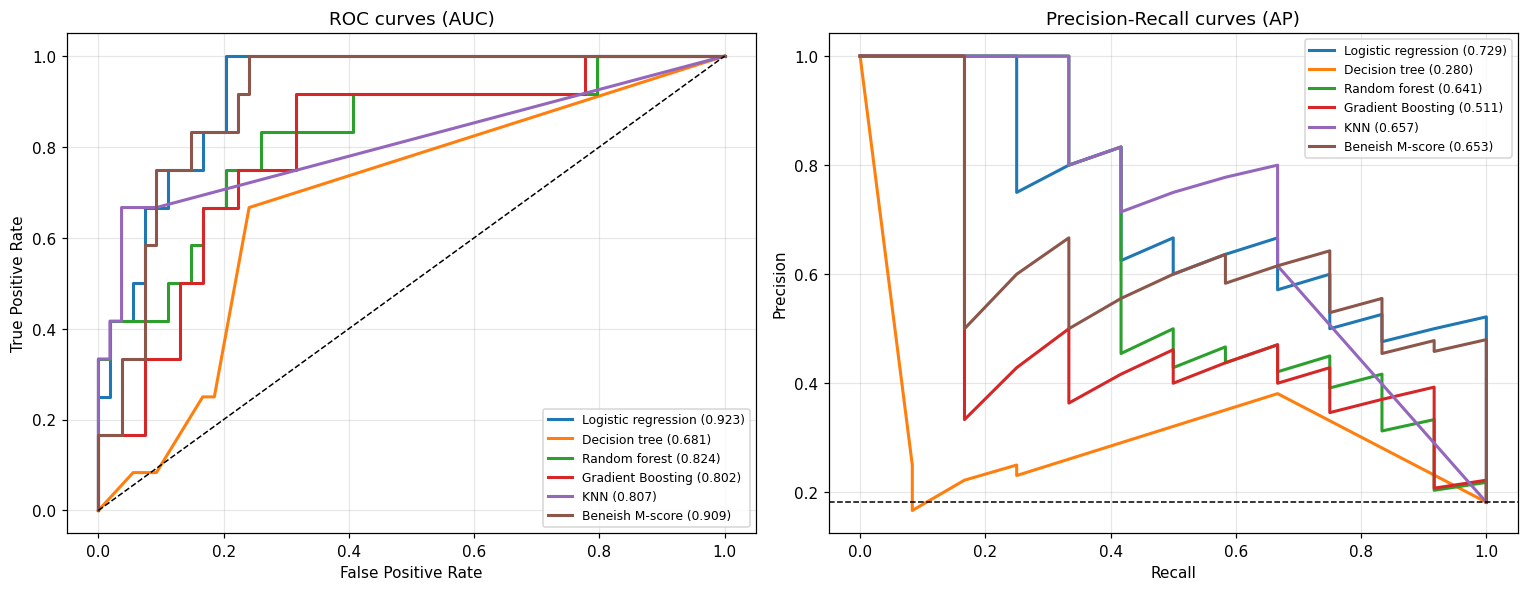

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
curves = [('Logistic regression', y_pred_prob), ('Decision tree', tree_prob),
          ('Random forest', rf_prob), (boost_name, boost_prob),
          ('KNN', knn_prob), ('Beneish M-score', m_test)]
for name, prob in curves:
    f, t, _ = roc_curve(Y_test, prob)
    axes[0].plot(f, t, lw=2, label=f'{name} ({roc_auc_score(Y_test, prob):.3f})')
    p_, r_, _ = precision_recall_curve(Y_test, prob)
    axes[1].plot(r_, p_, lw=2, label=f'{name} ({average_precision_score(Y_test, prob):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves (AUC)'); axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(alpha=0.3)
axes[1].axhline(Y_test.mean(), color='k', ls='--', lw=1)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves (AP)'); axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Reading the test results

- **The held-out set is consistent with the selection but does not decide it.** The logistic model records
  the best test ROC-AUC and PR-AUC of any model, but a 66-firm test set containing 12 manipulators cannot
  settle a 0.02 gap either. The choice was made in Section 4.6; this is confirmation, not the argument.
- **Watch the accuracy trap.** Random forest and KNN post higher *accuracy* than the recommended model
  while missing far more manipulators — KNN achieves perfect specificity essentially by flagging almost
  nothing. This is exactly the failure mode Q1 warned about, and it is why accuracy is not the selection
  criterion.
- **The published Beneish M-score performs comparably on ranking** (test ROC-AUC close to the fitted
  model's), which validates the variable set. Its apparent edge in the cross-validation table is an
  artefact of never being refitted, per the caveat in 4.5. The case for re-estimating rests on three
  things that are not raw discrimination: the fitted model returns a calibrated probability rather than an
  uncalibrated score, needs five variables rather than eight, and can be refitted annually as Indian
  accounting practice evolves, whereas the M-score is frozen at 1990s US data.

**Recommendation: deploy the reduced logistic regression, with the decision tree retained as an
explanatory aid and the M-score retained as an independent sanity check.**

---
# Q5. Deployment strategy for MCA Technologies  *(6 marks)*

## 5.0 Assumptions used in this section

The case does not supply either of the two numbers a deployment decision needs. Both are therefore
carried as **explicit scenario parameters**, with sensitivity analysis, and MCA should replace them with
client-specific data before going live.

| Parameter | Value used | Status | How MCA should set it |
|---|---|---|---|
| Deployment prevalence τ (population manipulator rate) | **4%** | **Assumption for illustration.** The modelling sample has a 17.7% manipulator prevalence, which may not represent the deployment population. | From the client's own historical detection rate, or regulatory enforcement statistics for the relevant exchange and period |
| Cost ratio cost(FN) : cost(FP) | **5 : 1** | **Assumption for illustration.** Not stated anywhere in the case. | From the client's average cost of a desk review versus its estimated exposure to acting on manipulated statements |

> **For illustration, a 4% deployment prevalence and a 5:1 false-negative to false-positive cost ratio are
> assumed. Neither figure is supplied by the case. MCA should calibrate both parameters using actual
> operational data before deployment.**

Sections 5.2 and 5.3 show how the recommendation moves as each is varied. **The deployment policy is a
function of business economics, not of statistics alone.**

## 5.1 Correcting for the base rate

A logistic model fitted on a sample whose prevalence differs from the deployment population produces
probabilities that are systematically wrong in level (though correctly ordered). For a case-control or
prevalence-shifted design, only the intercept needs correcting:

$$\beta_0^{\text{corrected}} = \beta_0 - \ln\!\left[\frac{\bar{y}_{\text{sample}}}{1-\bar{y}_{\text{sample}}}
\times \frac{1-\tau}{\tau}\right]$$

Slopes are unaffected. Skipping this step is the most common way a model like this fails in production.

In [41]:
POPULATION_RATE = 0.04                    # ASSUMPTION - see table above
sample_rate     = Y_train.mean()

def prior_correction(tau, sample_p=None):
    sample_p = sample_rate if sample_p is None else sample_p
    return np.log((sample_p / (1 - sample_p)) * ((1 - tau) / tau))

correction = prior_correction(POPULATION_RATE)
beta0_corr = final_logit_model.params['const'] - correction

print(f'Training-sample prevalence : {sample_rate:.4f}')
print(f'Assumed deployment rate    : {POPULATION_RATE:.4f}')
print(f'Intercept correction       : {correction:.4f}')
print(f'Intercept  {final_logit_model.params["const"]:.4f}  ->  {beta0_corr:.4f}')

def to_corrected(p, tau=POPULATION_RATE):
    p = np.clip(np.asarray(p, dtype=float), 1e-9, 1 - 1e-9)
    return 1 / (1 + np.exp(-(np.log(p / (1 - p)) - prior_correction(tau))))

Training-sample prevalence : 0.1753
Assumed deployment rate    : 0.0400
Intercept correction       : 1.6297
Intercept  -8.6055  ->  -10.2352


## 5.2 Sensitivity to the cost ratio

The threshold is re-derived from the **out-of-fold training predictions** for each cost scenario, then
each frozen threshold is applied once to the test set. Nothing here is tuned on test data.

In [42]:
sens_rows = []
for ratio in [1, 2, 3, 5, 10, 20]:
    costs = [total_cost(Y_train, (oof_prob >= t).astype(int), ratio) for t in THRESHOLDS]
    t_opt = float(THRESHOLDS[int(np.argmin(costs))])
    pred  = (y_pred_prob >= t_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, pred, labels=[0,1]).ravel()
    sens_rows.append([f'{ratio}:1', round(t_opt,2), round(to_corrected(t_opt),4),
                      tp/(tp+fn), tn/(tn+fp), fp, fn, (tp+tn)/len(Y_test)])

pd.DataFrame(sens_rows, columns=['cost(FN):cost(FP)','Threshold (raw)','Threshold (calibrated to 4%)',
                                 'Test sensitivity','Test specificity','False Pos','False Neg','Accuracy']).round(4)

,cost(FN):cost(FP),Threshold (raw),Threshold (calibrated to 4%),Test sensitivity,Test specificity,False Pos,False Neg,Accuracy
0,1:1,0.3600,0.0993,0.4167,0.9444,3,7,0.8485
1,2:1,0.1900,0.0440,0.5833,0.9259,4,5,0.8636
2,3:1,0.1800,0.0412,0.5833,0.9259,4,5,0.8636
3,5:1,0.1000,0.0213,0.8333,0.8333,9,2,0.8333
4,10:1,0.1000,0.0213,0.8333,0.8333,9,2,0.8333
5,20:1,0.0600,0.0124,1.0000,0.7407,14,0,0.7879


The pattern is the decision-relevant finding: **as the assumed cost of a missed manipulator rises, the
optimal cut-off falls and the review queue grows.** At 1:1 the model behaves like a conventional
classifier and misses most manipulators; by 20:1 it catches nearly all of them at roughly double the
false-positive load. MCA's clients sit at different points on this curve, so the threshold should be a
**configurable client parameter**, not a constant baked into the model.

## 5.3 Sensitivity to assumed prevalence

In [43]:
prev_rows = []
for tau in [0.02, 0.04, 0.08, float(sample_rate)]:
    prev_rows.append([f'{tau:.1%}', round(prior_correction(tau),4),
                      round(float(to_corrected(CHOSEN_THRESHOLD, tau)),4),
                      round(float(to_corrected(0.50, tau)),4)])
pd.DataFrame(prev_rows, columns=['Assumed prevalence τ','Intercept correction',
                                 'Amber boundary (calibrated)','Red boundary (calibrated)'])

,Assumed prevalence τ,Intercept correction,Amber boundary (calibrated),Red boundary (calibrated)
0,2.0%,2.3435,0.0106,0.0876
1,4.0%,1.6297,0.0213,0.1639
2,8.0%,0.8940,0.0435,0.2903
3,17.5%,0.0000,0.1000,0.5000


The *ranking* of firms is completely unaffected by τ — only the probability scale moves. This matters
commercially: MCA can ship one model and calibrate it per client, and a client that disagrees with the
assumed prevalence changes only the labels on the tiers, not which firms get investigated.

## 5.4 Recommended deployment

**Model.** Reduced logistic regression on DSRI, GMI, AQI, SGI and ACCR, fitted on the un-resampled sample
and refitted annually, with the intercept prior-corrected to each client's actual base rate. The decision
tree ships alongside as an explanation aid; the Beneish M-score runs in parallel as an independent check
and any material disagreement between the two is escalated.

**Operating point.** Threshold selected by cost minimisation on cross-validated training predictions, at
the client's own FN:FP ratio. Exposed as a configuration parameter, defaulted to the 5:1 scenario.

**Three-tier triage, not a binary verdict.** Boundaries are *derived* from the two cut-offs above, not
invented: the Amber boundary is the cost-optimal threshold, the Red boundary the strict 0.5 cut-off.

In [44]:
AMBER_RAW, RED_RAW = CHOSEN_THRESHOLD, 0.50
print(f'Amber boundary : raw {AMBER_RAW:.2f} -> calibrated {to_corrected(AMBER_RAW):.4f}')
print(f'Red boundary   : raw {RED_RAW:.2f} -> calibrated {to_corrected(RED_RAW):.4f}')

tiers = pd.cut(Y_pred_df['predicted_prob'], bins=[-0.001, AMBER_RAW, RED_RAW, 1.0],
               labels=['Green — routine', 'Amber — desk review', 'Red — forensic audit'])
tier_tbl = pd.DataFrame({'tier': tiers, 'actual': Y_test.values})
summary_tiers = tier_tbl.groupby('tier', observed=False).agg(firms=('actual','size'), manipulators=('actual','sum'))
summary_tiers['hit_rate'] = (summary_tiers['manipulators'] / summary_tiers['firms']).round(3)
summary_tiers['share_of_all_manipulators'] = (summary_tiers['manipulators'] / tier_tbl['actual'].sum()).round(3)
summary_tiers

Amber boundary : raw 0.10 -> calibrated 0.0213
Red boundary   : raw 0.50 -> calibrated 0.1639


,firms,manipulators,hit_rate,share_of_all_manipulators
tier,,,,
Green — routine,47,2,0.0430,0.1670
Amber — desk review,14,6,0.4290,0.5000
Red — forensic audit,5,4,0.8000,0.3330


| Tier | Raw score | Action |
|---|---|---|
| **Red** | > 0.50 | Full forensic review; management interviews; related-party and revenue-recognition testing |
| **Amber** | cost-optimal cut-off – 0.50 | Desk review by a senior analyst; examine the indices that drove the score |
| **Green** | below the cut-off | Routine handling; re-score at the next reporting cycle |

Note the tier hit-rates above are computed on a test set carrying the **sample** prevalence of 17.7%, so
they are optimistic relative to a live universe at 4%. The *capture rate* — the share of all manipulators
falling in Amber or Red — is the more transferable statistic.

**Delivery.** A batch/API service that ingests two consecutive years of published financials, computes
the five indices, and returns a probability, a tier, and the **top contributing variables for that firm**.
Analysts will not act on a bare number; they will act on "flagged because receivables grew far faster than
sales and accruals are in the top decile relative to peers".

**Governance and monitoring.**
- Refit annually; re-estimate the client's base rate every cycle — the correction is only as good as τ.
- Monitor population stability (PSI) on each index. Indian accounting standards and disclosure norms
  change, and the fitted relationship will decay.
- Log every prediction against the eventual outcome, to build the feedback data the current 39-positive
  sample badly lacks.
- **Human sign-off is mandatory** before any external communication. The model outputs risk, never a
  finding of fraud.

**Limitations to disclose to clients.**
- The fitted model uses 27 manipulators in the training sample, equivalent to approximately 5.4 events per
  variable in the final five-predictor specification. Coefficient magnitudes are imprecise and the model
  has not seen novel schemes.
- Labels come from firms *caught* manipulating. Sophisticated undetected manipulators sit in the
  non-manipulator class, biasing the model toward detecting crude manipulation.
- The indices capture accounting-ratio anomalies only. Off-balance-sheet vehicles, undisclosed
  related-party transactions and outright fabrication of the underlying books will not appear.
- Legal and reputational exposure: a "manipulator" label on a listed company is defamatory if published.
  Output is internal decision support only.

---
## Appendix: reusable scoring function

Driver attribution is expressed **relative to the non-manipulator median** rather than as a raw
log-odds contribution, so that an analyst reads "receivables are well above the clean-firm benchmark"
rather than an unanchored number.

In [45]:
BASELINE = df.loc[df[TARGET] == 0, significant_vars].median()
print('Non-manipulator benchmark (median):'); print(BASELINE.round(4))

def score_new_firms(new_df, tau=POPULATION_RATE, calibrated=True):
    # Score new firms. Expects the columns in significant_vars.
    b0 = final_logit_model.params['const']
    if calibrated:
        b0 = b0 - prior_correction(tau)
    contrib = pd.DataFrame({v: final_logit_model.params[v] * (new_df[v] - BASELINE[v])
                            for v in significant_vars})
    base_logit = b0 + sum(final_logit_model.params[v] * BASELINE[v] for v in significant_vars)
    prob = 1 / (1 + np.exp(-(base_logit + contrib.sum(axis=1))))

    amber = float(to_corrected(AMBER_RAW, tau)) if calibrated else AMBER_RAW
    red   = float(to_corrected(RED_RAW,   tau)) if calibrated else RED_RAW

    out = pd.DataFrame({'probability': prob.round(4)})
    out['tier'] = pd.cut(prob, bins=[-0.001, amber, red, 1.0], labels=['Green','Amber','Red'])
    out['top_driver']    = contrib.idxmax(axis=1)
    out['second_driver'] = contrib.apply(lambda r: r.drop(r.idxmax()).idxmax(), axis=1)
    out['driver_vs_benchmark'] = [f"{td}: {new_df[td].iloc[i]:.2f} vs benchmark {BASELINE[td]:.2f}"
                                  for i, td in enumerate(out['top_driver'])]
    return out

score_new_firms(X_test[significant_vars]).head(10)

Non-manipulator benchmark (median):
DSRI    1.0448
GMI     1.0000
AQI     1.0247
SGI     1.0806
ACCR   -0.0258
dtype: float64


,probability,tier,top_driver,second_driver,driver_vs_benchmark
209,0.0048,Green,ACCR,GMI,ACCR: 0.03 vs benchmark -0.03
213,0.0047,Green,SGI,GMI,SGI: 1.06 vs benchmark 1.08
188,0.0045,Green,SGI,GMI,SGI: 1.21 vs benchmark 1.08
46,0.0008,Green,AQI,GMI,AQI: 5.17 vs benchmark 1.02
23,0.9994,Red,DSRI,ACCR,DSRI: 14.00 vs benchmark 1.04
52,0.0002,Green,ACCR,GMI,ACCR: 0.01 vs benchmark -0.03
142,0.0070,Green,DSRI,GMI,DSRI: 1.37 vs benchmark 1.04
59,0.0031,Green,GMI,DSRI,GMI: 1.32 vs benchmark 1.00
197,0.0335,Amber,ACCR,SGI,ACCR: 0.11 vs benchmark -0.03
97,0.0037,Green,AQI,DSRI,AQI: 1.58 vs benchmark 1.02


---
### Note on deliverables

This notebook is **Deliverable B (the Python script)**. Deliverable A is a separate professionally written
report: cover page, one-page executive summary, and a main report of at most 20 pages following the
narrative **Problem → Data → Class imbalance → Logistic methodology → Results → Model evaluation →
Alternative models → Model selection → Deployment → Limitations → Conclusion**. The executive summary
should state the answer immediately: the recommended model, the most important predictors, the headline
performance figures, why sensitivity matters more than accuracy here, and the deployment recommendation.